In [1]:
from matplotlib.colors import ListedColormap
!pip install netCDF4
!pip install seaborn
!pip install scipy
!pip install fiona

In [2]:
from netCDF4 import Dataset, num2date
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import os
import xarray as xr
import seaborn as sns
import seaborn.objects as so
import numpy as np
import gc
from datetime import datetime
import glob
from scipy import stats
import geopandas as gpd
import rioxarray
import fiona
import shutil

# Bathymetry for Ireland and Northern Ireland
- Data for *Northern Ireland* is gathered from the EMODnet Map Viewer, https://emodnet.ec.europa.eu/geoviewer/, from the EMODnet Bathymetry - Depth - Mean depth rainbow colour (no land) layer. The mulitlayer bathymetric product is "EMODnet Digital Bathymetry (DTM)- 2024." Meta Data is accessible at https://emodnet.ec.europa.eu/geonetwork/srv/eng/catalog.search#/metadata/cf51df64-56f9-4a99-b1aa-36b8d7b743a1
- Data for the *Republic of Ireland* is gathered from INFOMAR Marine Data Download Portal, https://experience.arcgis.com/experience/3f2815ec89e745d2b65630429d06385c/page/Page-1?views=Download-Entire-Area#data_s=id%3AdataSource_30-IE_GSI_MI_Marine_Download_Seabed_Survey_Merged_Data_IE_Waters_WGS84_9234%3A643, from "Bathymetry 10m Bathymetry 10m WGS84 Floating Point GeoTIFF Projection: WGS84 Last updated: April 2026".

## First: Northern Ireland
Right now, this is covering the whole island of Ireland, but ROI of Ireland Areas will be replaced with INFOMAR data as it is higher resolution.

In [3]:
nor_ire = xr.open_dataset("C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/EMODnetMapViewer_IslandofIreland_Bathymetry_unzipped.nc")

In [4]:
nor_ire

<xarray.Dataset> Size: 875MB
Dimensions:             (latitude: 4174, longitude: 5822)
Coordinates:
  * latitude            (latitude) float64 33kB 51.2 51.21 51.21 ... 55.55 55.55
  * longitude           (longitude) float64 47kB -11.12 -11.12 ... -5.055 -5.054
Data variables:
    elevation           (latitude, longitude) float32 97MB ...
    value_count         (latitude, longitude) float64 194MB ...
    cdi_index           (latitude, longitude) float64 194MB ...
    interpolation_flag  (latitude, longitude) float32 97MB ...
    elevation_max       (latitude, longitude) float32 97MB ...
    elevation_min       (latitude, longitude) float32 97MB ...
    stdev               (latitude, longitude) float32 97MB ...
Attributes: (12/36)
    cdm_data_type:                    Grid
    comment:                          The data in the EMODnet Grid should not...
    Conventions:                      SeaDataNet_1.0 CF1.6, COARDS, ACDD-1.3
    creator_name:                     SeaDataNet
    creator_url:                      https://www.seadatanet.org/
    dtm_convention_version:           1.0
    ...                               ...
    sourceUrl:                        (local files)
    Southernmost_Northing:            51.20468749996878
    standard_name_vocabulary:         CF Standard Name Table v70
    summary:                          The data in the EMODnet Grid should not...
    title:                            The EMODnet Grid
    Westernmost_Easting:              -11.117187500014303

In [5]:
nor_ire.attrs

{'cdm_data_type': 'Grid',
 'comment': 'The data in the EMODnet Grid should not be used for navigation or any purpose relating to safety at sea.',
 'Conventions': 'SeaDataNet_1.0 CF1.6, COARDS, ACDD-1.3',
 'creator_name': 'SeaDataNet',
 'creator_url': 'https://www.seadatanet.org/',
 'dtm_convention_version': '1.0',
 'Easternmost_Easting': np.float64(-5.053645833345324),
 'geospatial_lat_max': np.float64(55.551562499964824),
 'geospatial_lat_min': np.float64(51.20468749996878),
 'geospatial_lat_resolution': np.float64(0.0010416666666657431),
 'geospatial_lat_units': 'degrees_north',
 'geospatial_lon_max': np.float64(-5.053645833345324),
 'geospatial_lon_min': np.float64(-11.117187500014303),
 'geospatial_lon_resolution': np.float64(0.001041666666666261),
 'geospatial_lon_units': 'degrees_east',
 'grid_mapping_comment': 'see Appendix F of cf convention 1.6',
 'grid_mapping_epsg_code': 'EPSG:4326',
 'grid_mapping_inverse_flattening': np.float64(298.257223563),
 'grid_mapping_long_name': 'g

In [6]:
nor_ire['elevation'].attrs

{'colorBarPalette': 'TopographyDepth',
 'comment': 'Gridded data are stored as a two-dimensional array of float values of elevation in metres, with negative values for bathymetric depths below the reference level and positive values for topographic heights above the reference level',
 'long_name': 'Elevation relative to Lowest Astronomical Tide datum',
 'sdn_P02_urn': 'SDN:P02::MBAN',
 'sdn_parameter_name': 'Elevation relative to Lowest Astronomical Tide datum',
 'sdn_parameter_urn': 'SDN:P01::HGHTALAT',
 'sdn_uom_name': 'Metres',
 'sdn_uom_urn': 'SDN:P06::ULAA',
 'standard_name': 'depth',
 'units': 'm'}

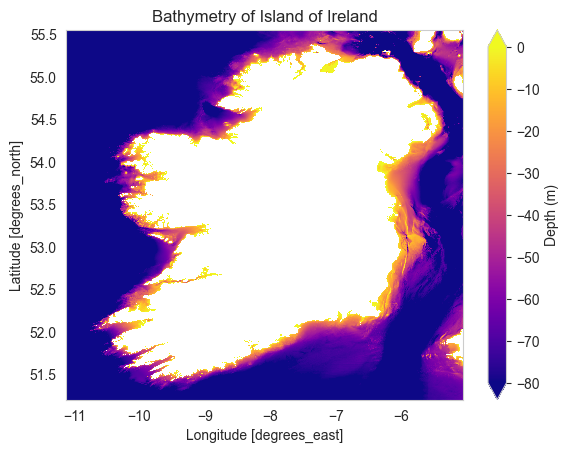

In [7]:
nor_ire['elevation'].plot(cmap='plasma',
    vmin=-80, vmax=0,
    cbar_kwargs={'label': 'Depth (m)'}
)
plt.title('Bathymetry of Island of Ireland')
plt.show()

The cell below will filter out only the area I am concerned with, 40 meters depth and above

In [8]:
nor_ire_40m = nor_ire.where((nor_ire['elevation'] >= -40) & (nor_ire['elevation'] <= 0), drop=False)

In [9]:
nor_ire_40m.to_netcdf("nor_ire_40m.nc")

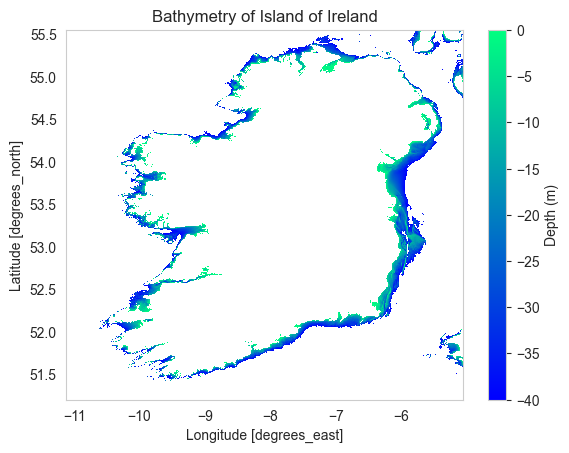

In [10]:
nor_ire_40m['elevation'].plot(cmap='winter',
    vmin=-40, vmax=0,
    cbar_kwargs={'label': 'Depth (m)'}
)
plt.title('Bathymetry of Island of Ireland')
plt.show()

Now want to get rid of scotland and wales in here, so going to use shapefile of Irelands EEZ from Marine Institute (https://data.marine.ie/geonetwork/srv/eng/catalog.search#/metadata/ie.marine.data:dataset.2139) - File Name: Irish Exclusive Economic Zone Maritime Boundary

**DID NOT WORK** - seems obvious now but IRE EEZ is only for the republic

In [11]:
eez_ire = gpd.read_file("C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/For Bathymetry/Irish EEZ/Maritime_Boundary_Exclusive_Economic_Zone.shp")
eez_ire


,gml_id,OBJECTID,beginLifes,endLifespa,datasetNam,localId,inspireId,inspireThe,version,zoneType,...,geograph_2,geograph_3,scale,coordinate,styleLayer,licence,qualitySta,dataProven,dataAccess,geometry
0,F59__1,1,2014-02-21T23:59:59,2016-07-05T10:30:00,Irish Exclusive Economic Zone Maritime Boundary,200M (EEZ),AU.MaritimeBoundary.ExclusiveEconomicZone.IE.D...,http://inspire.ec.europa.eu/theme/au,2016,http://inspire.ec.europa.eu/codelist/MaritimeZ...,...,http://inspire.ec.europa.eu/codelist/NameStatu...,http://dbpedia.org/resource/United_Nations_Con...,1:10000,http://www.opengis.net/def/crs/EPSG/0/4326,INSPIRE AU.ExclusiveEconomicZone Default Style...,https://creativecommons.org/licenses/by/4.0/,http://vocab.nerc.ac.uk/collection/L20/current/1/,http://dbpedia.org/resource/Marine_Institute_I...,http://atlas.marine.ie/arcgis/rest/services/Ad...,"LINESTRING (-14.33103 56.57719, -14.33103 56.5..."
1,F59__2,2,2014-02-21T23:59:59,2016-07-05T10:30:00,Irish Exclusive Economic Zone Maritime Boundary,S.I. No. 86 of 2014,AU.MaritimeBoundary.ExclusiveEconomicZone.IE.D...,http://inspire.ec.europa.eu/theme/au,2016,http://inspire.ec.europa.eu/codelist/MaritimeZ...,...,http://inspire.ec.europa.eu/codelist/NameStatu...,http://dbpedia.org/resource/United_Nations_Con...,1:10000,http://www.opengis.net/def/crs/EPSG/0/4326,INSPIRE AU.ExclusiveEconomicZone Default Style...,https://creativecommons.org/licenses/by/4.0/,http://vocab.nerc.ac.uk/collection/L20/current/1/,http://dbpedia.org/resource/Marine_Institute_I...,http://atlas.marine.ie/arcgis/rest/services/Ad...,"MULTILINESTRING ((-5.82564 53.87035, -5.36667 ..."
2,F59__3,3,2014-02-21T23:59:59,2016-07-05T10:30:00,Irish Exclusive Economic Zone Maritime Boundary,S.I. No. 86 of 2014,AU.MaritimeBoundary.ExclusiveEconomicZone.IE.D...,http://inspire.ec.europa.eu/theme/au,2016,http://inspire.ec.europa.eu/codelist/MaritimeZ...,...,http://inspire.ec.europa.eu/codelist/NameStatu...,http://dbpedia.org/resource/United_Nations_Con...,1:10000,http://www.opengis.net/def/crs/EPSG/0/4326,INSPIRE AU.ExclusiveEconomicZone Default Style...,https://creativecommons.org/licenses/by/4.0/,http://vocab.nerc.ac.uk/collection/L20/current/1/,http://dbpedia.org/resource/Marine_Institute_I...,http://atlas.marine.ie/arcgis/rest/services/Ad...,"LINESTRING (-6.74413 55.41486, -6.75 55.46667,..."


In [12]:
if eez_ire.crs is None:
    eez_ire = eez_ire.set_crs("EPSG:4326")
else:
    eez_ire = eez_ire.to_crs("EPSG:4326")

<Axes: >

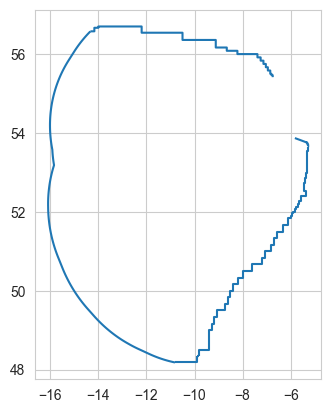

In [13]:
eez_ire.plot()

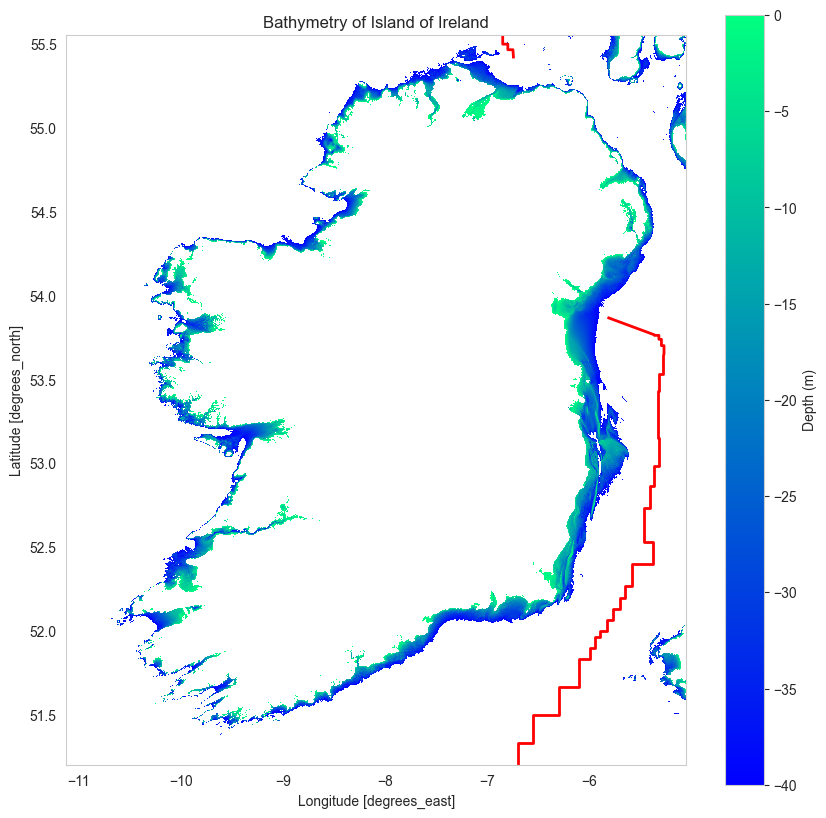

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))

nor_ire_40m['elevation'].plot(ax=ax,cmap='winter',
    vmin=-40, vmax=0,
    cbar_kwargs={'label': 'Depth (m)'}
)
eez_ire.plot(ax=ax, edgecolor='red', linewidth=2, label="EEZ")
plt.title('Bathymetry of Island of Ireland')
plt.show()

**USING EEZ did not work (bummer).**

**Second Attempt**: Make a custom mask to block out Scotland/Wales/England using google earth kmz

In [15]:
# this is what fiona is for
fiona.drvsupport.supported_drivers['KML'] = 'rw'

In [16]:
## google exports in EPSG:4326 so don't have to convert
irish_waters = gpd.read_file("C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/For Bathymetry/Just_Irish_Waters.kmz")

In [17]:
## need to make sure to set the CRS to EPSG:4326, even though it already has it in attributes (doesn't work without)
nor_ire_40m = nor_ire_40m.rio.write_crs("EPSG:4326")

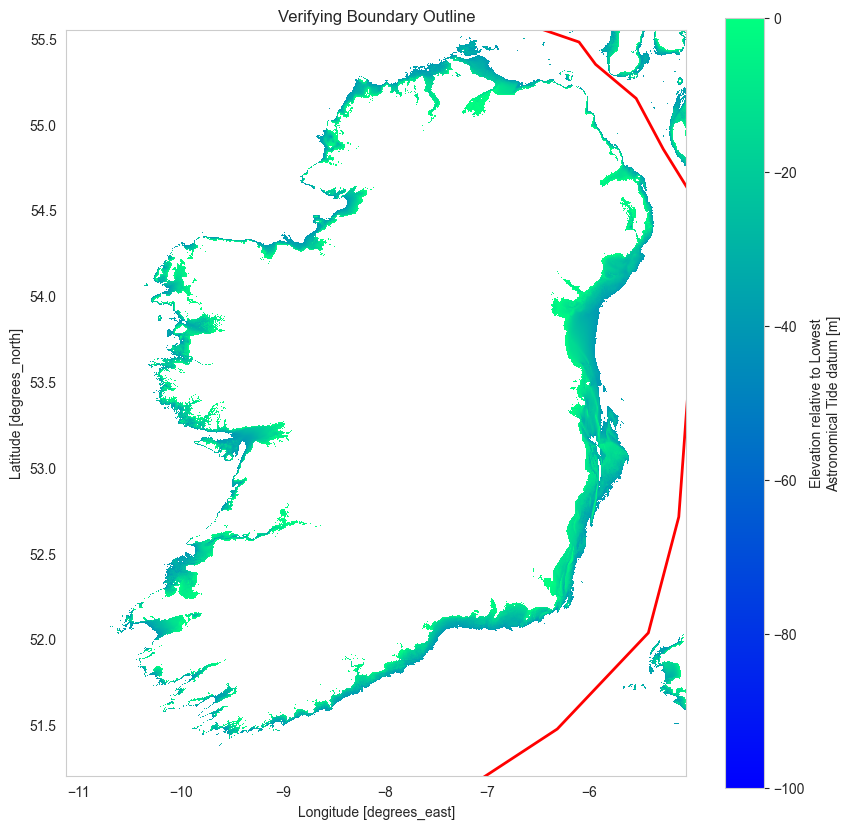

In [18]:
## check that the boundary is right before masking
fig, ax = plt.subplots(figsize=(10, 10))
nor_ire_40m['elevation'].plot(ax=ax, cmap='winter', vmin=-100, vmax=0)
irish_waters.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
plt.title("Verifying Boundary Outline")
plt.show()

In [19]:
nor_ire_40m_masked = nor_ire_40m.rio.clip(irish_waters.geometry, drop=False)

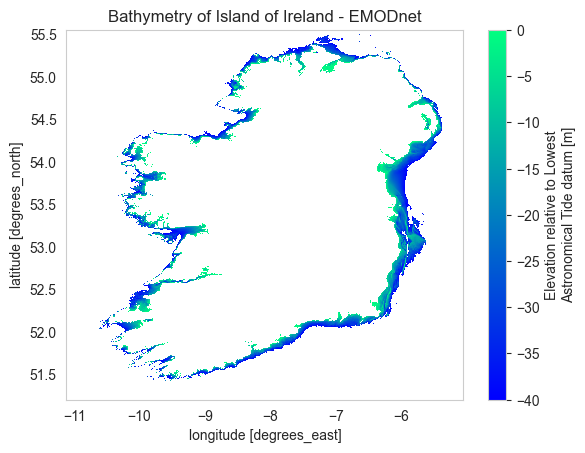

In [20]:
nor_ire_40m_masked['elevation'].plot(cmap='winter', vmin=-40, vmax=0)
plt.title('Bathymetry of Island of Ireland - EMODnet')
plt.show()

In [21]:
nor_ire_40m_masked.to_netcdf("nor_ire_40m_masked.nc")
## this saves the netCDF file for 40m depth and above, masked for only Irish waters (sorry Scotland)

Great! That is the first map of the Island of Ireland, but now I want to add the INFOMAR higher resolution data for the Republic of Ireland

## Republic of Ireland - INFOMAR high resolution bathymetry

In [49]:
rep_ire = rioxarray.open_rasterio("C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/For Bathymetry/INFOMAR - Rep of Ireland/IE_GSI_MI_Bathymetry_10m_Inshore_IE_WGS84_LAT_TIFF.tif", chunks={'x':2000, 'y':2000})
## chucks because it is a ma-hoosive dataset

In [50]:
#want to filter it the the depth I want
rep_ire_40m = rep_ire.where((rep_ire >= -40) & (rep_ire <=0), drop=False).squeeze()

As it is (10m resolution), I cannot make a plot to take a look at it, so need to move on to coursening resolution of both datasets to match copernicus data.
Also, both depths are taken at Lowest Astronomical Tide, so don't have to worry about a mismatch there.

In [51]:
#rep_ire_40m = rep_ire_40m.compute()

### skip this part, plan did not work

In [25]:
#plt.figure(figsize=(12,10))
#rep_ire_40m.plot.imshow(
#    cmap='winter',
#    vmin=-40, vmax=0,
#    cbar_kwargs={'label': 'Depth (m)'}
#)
#plt.title("INFOMAR Bathymetry of Republic of Ireland")
#plt.show()
##this is made of commments because it made everything crashhhh

**ISSUE**: INFOMAR data uses way to much RAM, need to crop it down piece by piece to try to get it to what I want. **MORE ISSUES: this is not working, do not run again**

In [26]:
## use boundaries of the other map
#min_lon = float(nor_ire_40m_masked.longitude.min())
#max_lon = float(nor_ire_40m_masked.longitude.max())
#min_lat = float(nor_ire_40m_masked.latitude.min())
#max_lat = float(nor_ire_40m_masked.latitude.max())
#print("--- Frame Coordinates Extracted ---")
#print(f"Longitude Frame: {min_lon} to {max_lon}")
#print(f"Latitude Frame:  {min_lat} to {max_lat}\n")

In [27]:
#rep_ire_40m_crop = rep_ire_40m.sel(x=slice(min_lon, max_lon), y=slice(max_lat, min_lat))

In [28]:
#plt.figure(figsize=(12,10))
#rep_ire_40m_crop.plot.imshow(
    #cmap='winter',
    #vmin=-40, vmax=0,
    #cbar_kwargs={'label': 'Depth (m)'}
#)
#plt.title("INFOMAR Bathymetry of Republic of Ireland")
#plt.show()

## Resample and Reproject to Match Copernicus 1km resolution
INFOMAR (rep_ire_40m) is at 10m*10m resolution

EMODnet (nor_ire_40m) is at 115m*115m (1/16 arc minute) resolution according to the metadata. To convert this to the 1km resolution (1km at equator is 1 arc minute), need to do: Pixel_size = 1/16 * 1/16 arc minute = 0.0625 arc minutes. Then to get the factor needed: 1 arc minute/ 0.0625 arc minutes = 16. But! that is at the equator. In Ireland, the actual width of 1 arc minute would be 1km*cos(latitude). To get the *exact* value, need to use **Reprojection Grid Matching**, "rio.reproject_match".

### NI/Whole Island First
1.Open the master copernicus file with the pixel size I want to match, chunk it, and make sure that it is in WGS84 (EPSG:4326)

In [52]:
#kd490_trend = rioxarray.open_rasterio("C:/Users/25298423/PycharmProjects/JupyterProject1/KD490_trend.nc", chunks=True)
#kd490_trend = kd490_trend.rio.write_crs("EPSG:4326")

In [53]:
file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/*.nc'))
kd490_ds = xr.open_mfdataset(file_list, concat_dim='time', combine='nested')
## combine all the files into one, massive DataSet so that we can do comparisons over years
kd490_array = kd490_ds['KD490']

In [54]:
kd490_array = kd490_array.rio.write_crs("EPSG:4326")

In [103]:
kd490_array = kd490_array.rename({'latitude':'y', 'longitude':'x'})

2. Open up nor_ire_40m_masked lazily (dask chunks), and make sure that it is in the same projection

In [104]:
nor_ire_chunks = rioxarray.open_rasterio("C:/Users/25298423/PycharmProjects/JupyterProject1/nor_ire_40m_masked.nc", chunks=True)
if nor_ire_chunks.rio.crs is None:
    nor_ire_chunks = nor_ire_chunks.rio.write_crs("EPSG:4326")

3. Use rio.reproject_match to get them to match exactly

In [172]:
nor_ire_1km = nor_ire_chunks.rio.reproject_match(kd490_array)

In [173]:
nor_ire_1km

<xarray.Dataset> Size: 47MB
Dimensions:             (band: 1, x: 1248, y: 1056)
Coordinates:
  * band                (band) int64 8B 1
  * x                   (x) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
  * y                   (y) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
    spatial_ref         int64 8B 0
Data variables:
    elevation           (band, y, x) float32 5MB nan nan nan nan ... nan nan nan
    value_count         (band, y, x) float64 11MB nan nan nan ... nan nan nan
    cdi_index           (band, y, x) float64 11MB nan nan nan ... nan nan nan
    interpolation_flag  (band, y, x) float32 5MB nan nan nan nan ... nan nan nan
    elevation_max       (band, y, x) float32 5MB nan nan nan nan ... nan nan nan
    elevation_min       (band, y, x) float32 5MB nan nan nan nan ... nan nan nan
    stdev               (band, y, x) float32 5MB nan nan nan nan ... nan nan nan
Attributes: (12/36)
    cdm_data_type:                    Grid
    comment:                          The data in the EMODnet Grid should not...
    Conventions:                      SeaDataNet_1.0 CF1.6, COARDS, ACDD-1.3
    creator_name:                     SeaDataNet
    creator_url:                      https://www.seadatanet.org/
    dtm_convention_version:           1.0
    ...                               ...
    sourceUrl:                        (local files)
    Southernmost_Northing:            51.20468749996878
    standard_name_vocabulary:         CF Standard Name Table v70
    summary:                          The data in the EMODnet Grid should not...
    title:                            The EMODnet Grid
    Westernmost_Easting:              -11.1171875000143

4. Want to make sure y comes first and then x

In [174]:
nor_ire_1km = nor_ire_1km.transpose('band','y','x')

In [175]:
nor_ire_1km['elevation']

<xarray.DataArray 'elevation' (band: 1, y: 1056, x: 1248)> Size: 5MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1, 1056, 1248), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float32 4kB 48.01 48.02 48.03 48.04 ... 58.97 58.98 58.99
  * x            (x) float32 5kB -14.99 -14.98 -14.97 ... -2.026 -2.016 -2.005
    spatial_ref  int64 8B 0
Attributes: (12/38)
    latitude#actual_range:          [51.2046875 55.5515625]
    latitude#axis:                  Y
    latitude#ioos_category:         Location
    latitude#long_name:             latitude
    latitude#sdn_P02_urn:           SDN:P02::ALAT
    latitude#sdn_parameter_name:    Latitude north
    ...                             ...
    sdn_uom_urn:                    SDN:P06::ULAA
    standard_name:                  depth
    units:                          m
    scale_factor:                   1.0
    add_offset:                     0.0
    _FillValue:                     nan

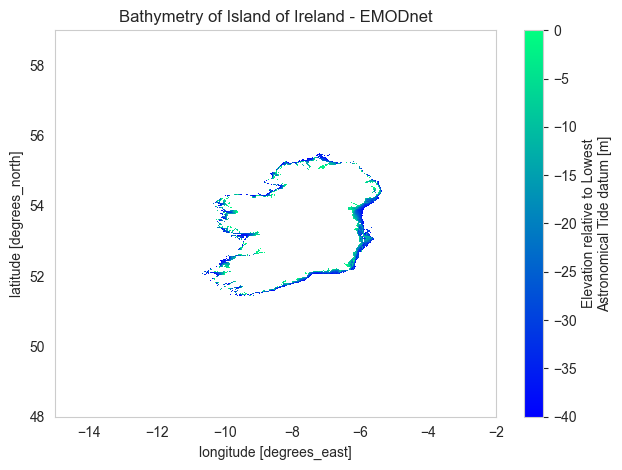

In [167]:
nor_ire_1km['elevation'].plot(cmap='winter', vmin=-40, vmax=0)
plt.title('Bathymetry of Island of Ireland - EMODnet')
plt.tight_layout()
plt.show()

Plot is really far away, want to use original lat longs to alter

In [168]:
## use boundaries of the other map
min_lon = float(nor_ire_40m_masked.longitude.min())
max_lon = float(nor_ire_40m_masked.longitude.max()-0.1)
min_lat = float(nor_ire_40m_masked.latitude.min())
max_lat = float(nor_ire_40m_masked.latitude.max())
print("--- Frame Coordinates Extracted ---")
print(f"Longitude Frame: {min_lon} to {max_lon}")
print(f"Latitude Frame:  {min_lat} to {max_lat}\n")

--- Frame Coordinates Extracted ---
Longitude Frame: -11.117187500014303 to -5.1536458333453234
Latitude Frame:  51.20468749996878 to 55.551562499964824



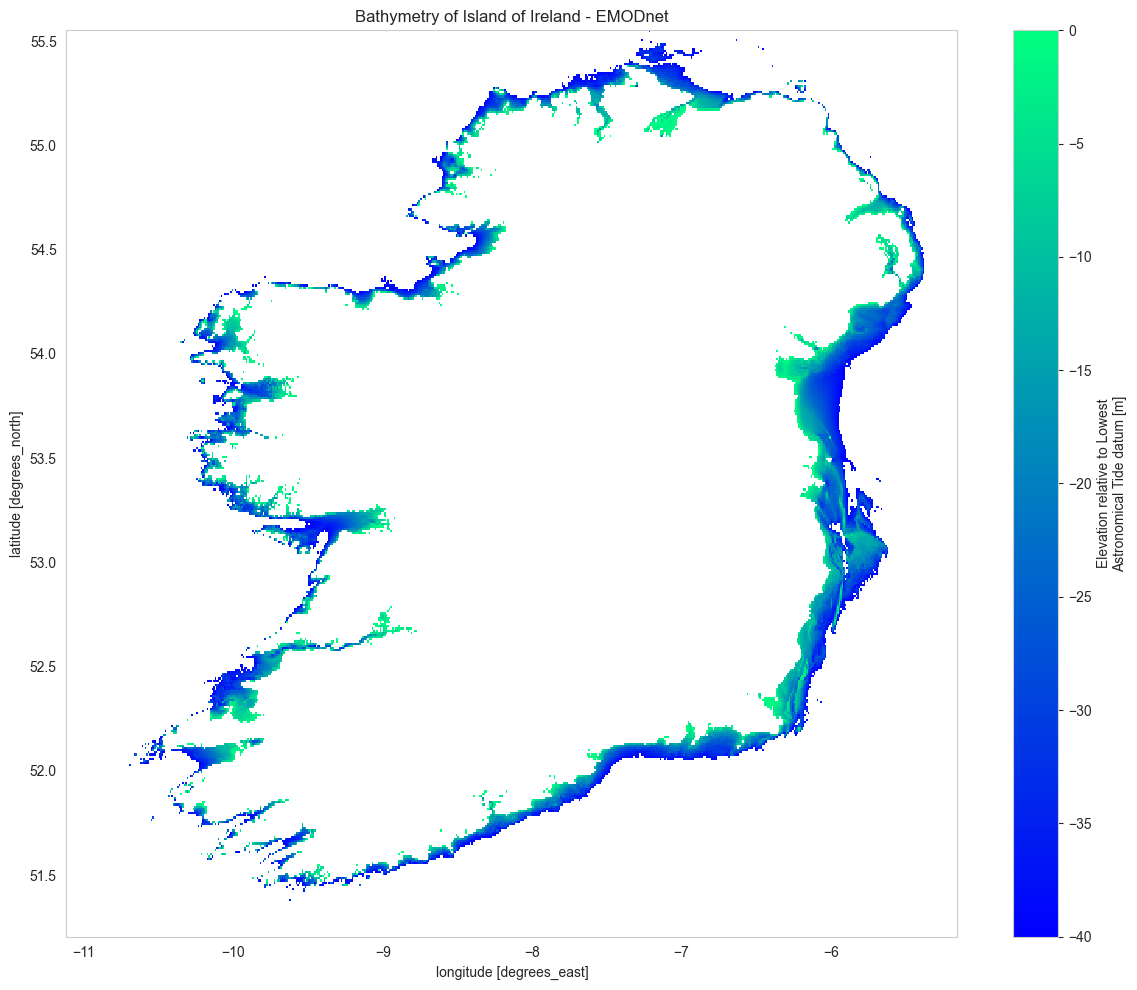

In [169]:
plt.figure(figsize=(12, 10))
nor_ire_1km['elevation'].plot(cmap='winter', vmin=-40, vmax=0)
plt.title('Bathymetry of Island of Ireland - EMODnet')
plt.xlim(min_lon, max_lon)
plt.ylim(min_lat, max_lat)
plt.tight_layout()
plt.show()

### INFOMAR/ROI Now

1. Already have the copernicus file in the right projection and loaded under 'kd490_array'
2. Already have the infomar ROI data loaded in chunks and projected to ESPG:4326 under 'rep_ire_40m'
3. Coursen 'rep_ire_40m' to 1km using x=100 and y=100 using .coarsen() and .mean()

In [143]:
rep_ire_1km = rep_ire_40m.coarsen(x=100, y=100, boundary='trim').mean()

In [144]:
rep_ire_1km

<xarray.DataArray (y: 653, x: 560)> Size: 1MB
dask.array<mean_agg-aggregate, shape=(653, 560), dtype=float32, chunksize=(20, 20), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 5kB 56.18 56.16 56.15 56.14 ... 48.47 48.46 48.45
  * x            (x) float64 4kB -11.77 -11.76 -11.74 ... -5.168 -5.156 -5.145
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes: (12/16)
    DataType:                Generic
    AREA_OR_POINT:           Area
    RepresentationType:      ATHEMATIC
    STATISTICS_COUNT:        1208969019.0
    STATISTICS_COVARIANCES:  1817.738129276311
    STATISTICS_MAXIMUM:      63.052402496338
    ...                      ...
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       42.634940240093
    _FillValue:              3.4e+38
    scale_factor:            1.0
    add_offset:              0.0
    units:                   metre

3.5 Need to transpose rep_ire_1km to make y come first and then x

In [148]:
rep_ire_1km = rep_ire_1km.transpose('y','x')

In [149]:
rep_ire_1km

<xarray.DataArray (y: 653, x: 560)> Size: 1MB
dask.array<transpose, shape=(653, 560), dtype=float32, chunksize=(20, 20), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 5kB 56.18 56.16 56.15 56.14 ... 48.47 48.46 48.45
  * x            (x) float64 4kB -11.77 -11.76 -11.74 ... -5.168 -5.156 -5.145
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes: (12/16)
    DataType:                Generic
    AREA_OR_POINT:           Area
    RepresentationType:      ATHEMATIC
    STATISTICS_COUNT:        1208969019.0
    STATISTICS_COVARIANCES:  1817.738129276311
    STATISTICS_MAXIMUM:      63.052402496338
    ...                      ...
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       42.634940240093
    _FillValue:              3.4e+38
    scale_factor:            1.0
    add_offset:              0.0
    units:                   metre

4. Use .rio.reproject_match() to make sure that rep_ire_1km is matching kd490_array

In [150]:
rep_ire_1km= rep_ire_1km.rio.reproject_match(kd490_array)

In [151]:
rep_ire_1km

<xarray.DataArray (y: 1056, x: 1248)> Size: 5MB
array([[3.4e+38, 3.4e+38, 3.4e+38, ..., 3.4e+38, 3.4e+38, 3.4e+38],
       [3.4e+38, 3.4e+38, 3.4e+38, ..., 3.4e+38, 3.4e+38, 3.4e+38],
       [3.4e+38, 3.4e+38, 3.4e+38, ..., 3.4e+38, 3.4e+38, 3.4e+38],
       ...,
       [3.4e+38, 3.4e+38, 3.4e+38, ..., 3.4e+38, 3.4e+38, 3.4e+38],
       [3.4e+38, 3.4e+38, 3.4e+38, ..., 3.4e+38, 3.4e+38, 3.4e+38],
       [3.4e+38, 3.4e+38, 3.4e+38, ..., 3.4e+38, 3.4e+38, 3.4e+38]],
      shape=(1056, 1248), dtype=float32)
Coordinates:
  * y            (y) float32 4kB 48.01 48.02 48.03 48.04 ... 58.97 58.98 58.99
  * x            (x) float32 5kB -14.99 -14.98 -14.97 ... -2.026 -2.016 -2.005
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes: (12/16)
    DataType:                Generic
    AREA_OR_POINT:           Area
    RepresentationType:      ATHEMATIC
    STATISTICS_COUNT:        1208969019.0
    STATISTICS_COVARIANCES:  1817.738129276311
    STATISTICS_MAXIMUM:      63.052402496338
    ...                      ...
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       42.634940240093
    scale_factor:            1.0
    add_offset:              0.0
    units:                   metre
    _FillValue:              3.4e+38

C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\matplotlib\colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


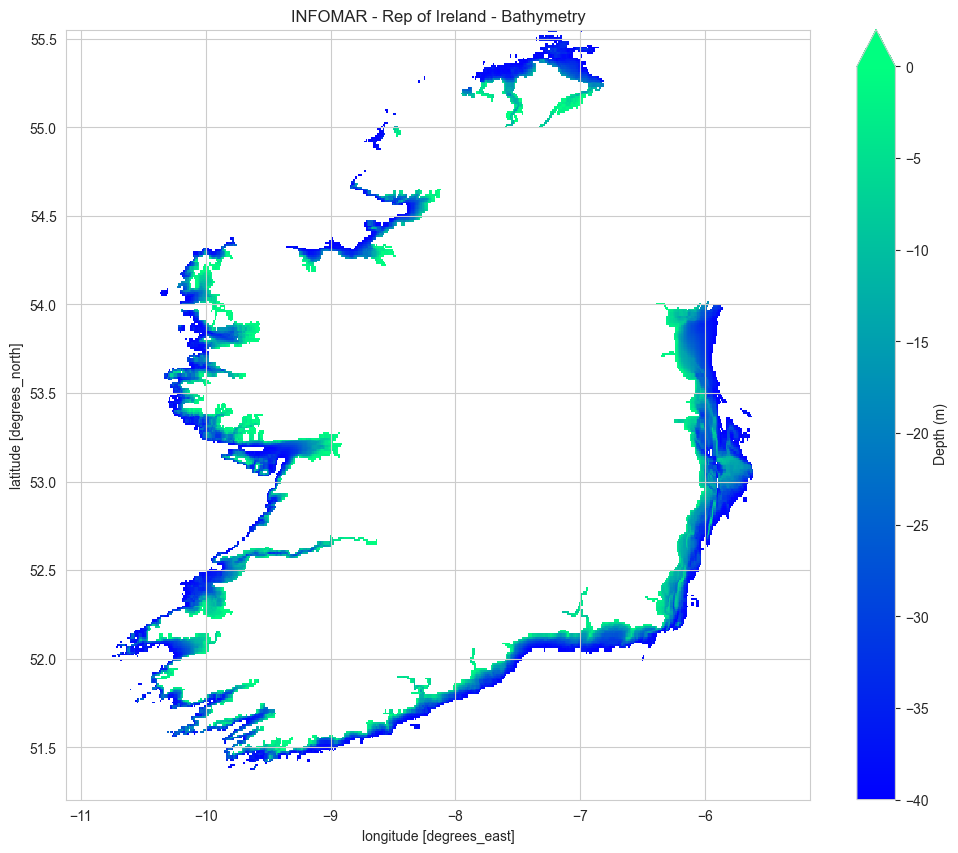

In [152]:
plt.figure(figsize=(12,10))
rep_ire_1km.squeeze().plot.imshow(
    cmap='winter',
    vmin=-40,
    vmax=0,
    cbar_kwargs = {'label': 'Depth (m)'})
plt.xlim(min_lon, max_lon)
plt.ylim(min_lat, max_lat)
plt.title('INFOMAR - Rep of Ireland - Bathymetry')
plt.show()

Great! got them both plotted and in the right projection, but now I want to slice both of them down to the boundaries I had for NI dataset to get rid of blank spaces.

5. Use .sel() on both datasets to make them the same size and eliminate unnecessary 0s

In [176]:
nor_ire_1km = nor_ire_1km.sel(
    x=slice(min_lon, max_lon),
    y=slice(min_lat, max_lat),
)

rep_ire_1km = rep_ire_1km.sel(
    x=slice(min_lon, max_lon),
    y=slice(min_lat, max_lat),
)

In [177]:
nor_ire_1km

<xarray.Dataset> Size: 9MB
Dimensions:             (band: 1, x: 572, y: 417)
Coordinates:
  * band                (band) int64 8B 1
  * x                   (x) float32 2kB -11.11 -11.1 -11.09 ... -5.172 -5.161
  * y                   (y) float32 2kB 51.21 51.22 51.23 ... 55.53 55.54 55.55
    spatial_ref         int64 8B 0
Data variables:
    elevation           (band, y, x) float32 954kB nan nan nan ... nan nan nan
    value_count         (band, y, x) float64 2MB nan nan nan nan ... nan nan nan
    cdi_index           (band, y, x) float64 2MB nan nan nan nan ... nan nan nan
    interpolation_flag  (band, y, x) float32 954kB nan nan nan ... nan nan nan
    elevation_max       (band, y, x) float32 954kB nan nan nan ... nan nan nan
    elevation_min       (band, y, x) float32 954kB nan nan nan ... nan nan nan
    stdev               (band, y, x) float32 954kB nan nan nan ... nan nan nan
Attributes: (12/36)
    cdm_data_type:                    Grid
    comment:                          The data in the EMODnet Grid should not...
    Conventions:                      SeaDataNet_1.0 CF1.6, COARDS, ACDD-1.3
    creator_name:                     SeaDataNet
    creator_url:                      https://www.seadatanet.org/
    dtm_convention_version:           1.0
    ...                               ...
    sourceUrl:                        (local files)
    Southernmost_Northing:            51.20468749996878
    standard_name_vocabulary:         CF Standard Name Table v70
    summary:                          The data in the EMODnet Grid should not...
    title:                            The EMODnet Grid
    Westernmost_Easting:              -11.1171875000143

In [178]:
rep_ire_1km

<xarray.DataArray (y: 417, x: 572)> Size: 954kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(417, 572), dtype=float32)
Coordinates:
  * y            (y) float32 2kB 51.21 51.22 51.23 51.24 ... 55.53 55.54 55.55
  * x            (x) float32 2kB -11.11 -11.1 -11.09 ... -5.182 -5.172 -5.161
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes: (12/16)
    DataType:                Generic
    AREA_OR_POINT:           Area
    RepresentationType:      ATHEMATIC
    STATISTICS_COUNT:        1208969019.0
    STATISTICS_COVARIANCES:  1817.738129276311
    STATISTICS_MAXIMUM:      63.052402496338
    ...                      ...
    STATISTICS_SKIPFACTORY:  1
    STATISTICS_STDDEV:       42.634940240093
    scale_factor:            1.0
    add_offset:              0.0
    units:                   metre
    _FillValue:              3.4e+38

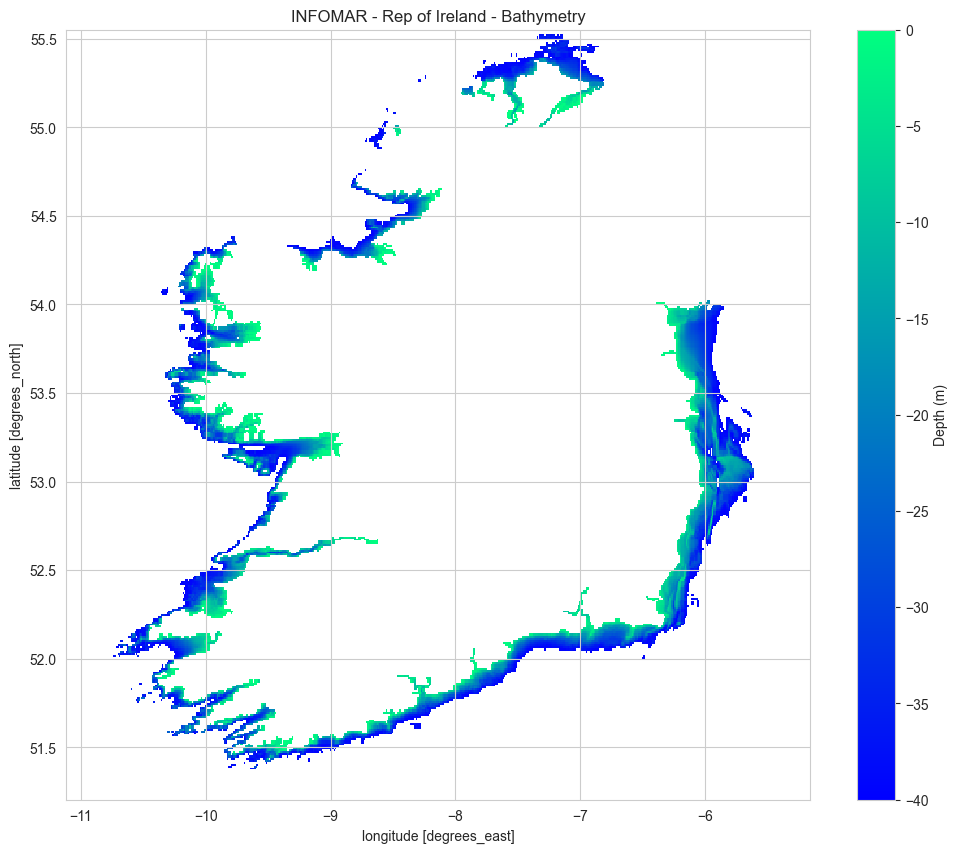

In [179]:
plt.figure(figsize=(12,10))
rep_ire_1km.squeeze().plot.imshow(
    cmap='winter',
    vmin=-40,
    vmax=0,
    cbar_kwargs = {'label': 'Depth (m)'})
plt.xlim(min_lon, max_lon)
plt.ylim(min_lat, max_lat)
plt.title('INFOMAR - Rep of Ireland - Bathymetry')
plt.show()

great! boundaries are sorted to not make the map so far away, but I want to check that they are exactly the same for the part where I combine them

In [180]:
## use boundaries of the other map
ni_min_lon = float(nor_ire_1km.y.min())
ni_max_lon = float(nor_ire_1km.y.max()-0.1)
ni_min_lat = float(nor_ire_1km.x.min())
ni_max_lat = float(nor_ire_1km.x.max())
print("--- Frame Coordinates Extracted for nor_ire_1km ---")
print(f"Longitude Frame: {ni_min_lon} to {ni_max_lon}")
print(f"Latitude Frame:  {ni_min_lat} to {ni_max_lat}\n")

--- Frame Coordinates Extracted for nor_ire_1km ---
Longitude Frame: 51.21354293823242 to 55.446875
Latitude Frame:  -11.109374046325684 to -5.161457061767578



In [181]:
## use boundaries of the other map
roi_min_lon = float(rep_ire_1km.y.min())
roi_max_lon = float(rep_ire_1km.y.max()-0.1)
roi_min_lat = float(rep_ire_1km.x.min())
roi_max_lat = float(rep_ire_1km.x.max())
print("--- Frame Coordinates Extracted for rep_ire_1km ---")
print(f"Longitude Frame: {roi_min_lon} to {roi_max_lon}")
print(f"Latitude Frame:  {roi_min_lat} to {roi_max_lat}\n")

--- Frame Coordinates Extracted for rep_ire_1km ---
Longitude Frame: 51.21354293823242 to 55.446875
Latitude Frame:  -11.109374046325684 to -5.161457061767578



In [182]:
print(ni_min_lon == roi_min_lon)
print(ni_max_lon == roi_max_lon)
print(ni_min_lat == roi_min_lat)
print(ni_max_lat == roi_max_lat)

True
True
True
True


great! all checks out visually and behind the scenes.

### Combine datasets into one file where INFOMAR takes precedence
1. use ".combine_first()" to get them together

In [183]:
nor_ire_snapped = nor_ire_1km.rio.reproject_match(rep_ire_1km)

In [184]:
coast_bath = rep_ire_1km.combine_first(nor_ire_1km)

In [185]:
coast_bath = coast_bath.transpose('band', 'y','x')
coast_bath

<xarray.Dataset> Size: 9MB
Dimensions:             (y: 417, x: 572, band: 1)
Coordinates:
  * y                   (y) float32 2kB 51.21 51.22 51.23 ... 55.53 55.54 55.55
  * x                   (x) float32 2kB -11.11 -11.1 -11.09 ... -5.172 -5.161
  * band                (band) int64 8B 1
    spatial_ref         int64 8B 0
Data variables:
    elevation           (band, y, x) float32 954kB nan nan nan ... nan nan nan
    value_count         (band, y, x) float64 2MB nan nan nan nan ... nan nan nan
    cdi_index           (band, y, x) float64 2MB nan nan nan nan ... nan nan nan
    interpolation_flag  (band, y, x) float32 954kB nan nan nan ... nan nan nan
    elevation_max       (band, y, x) float32 954kB nan nan nan ... nan nan nan
    elevation_min       (band, y, x) float32 954kB nan nan nan ... nan nan nan
    stdev               (band, y, x) float32 954kB nan nan nan ... nan nan nan
Attributes: (12/36)
    cdm_data_type:                    Grid
    comment:                          The data in the EMODnet Grid should not...
    Conventions:                      SeaDataNet_1.0 CF1.6, COARDS, ACDD-1.3
    creator_name:                     SeaDataNet
    creator_url:                      https://www.seadatanet.org/
    dtm_convention_version:           1.0
    ...                               ...
    sourceUrl:                        (local files)
    Southernmost_Northing:            51.20468749996878
    standard_name_vocabulary:         CF Standard Name Table v70
    summary:                          The data in the EMODnet Grid should not...
    title:                            The EMODnet Grid
    Westernmost_Easting:              -11.1171875000143

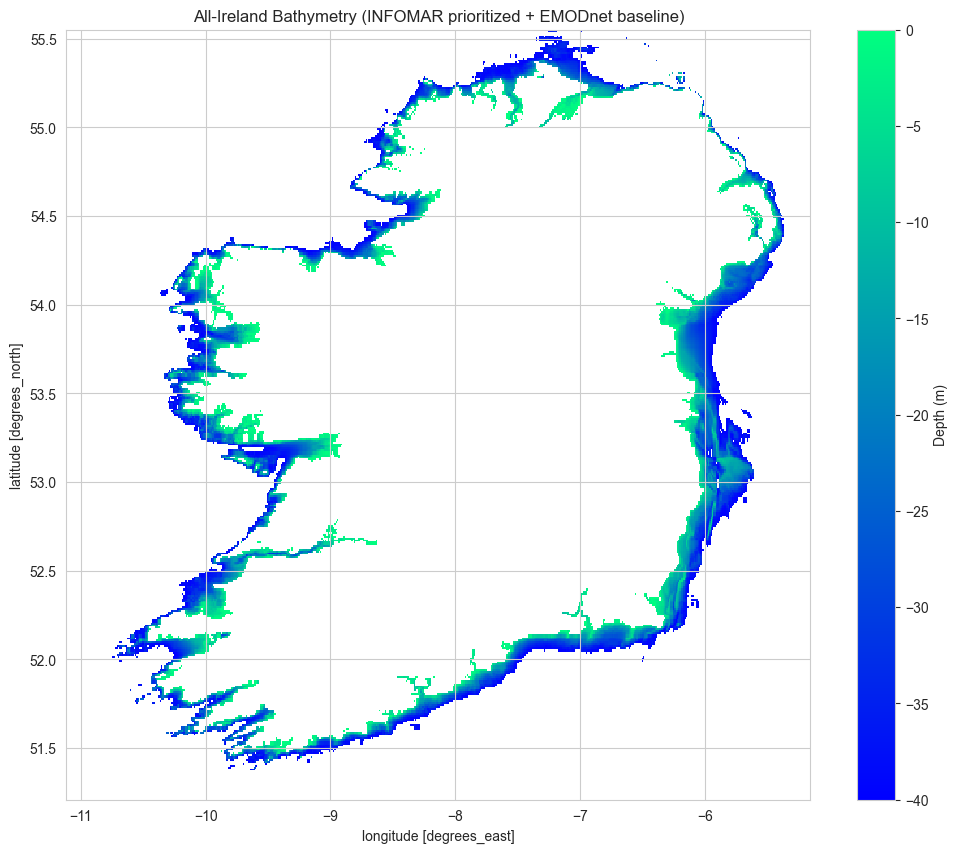

In [186]:
plt.figure(figsize=(12, 10))
coast_bath['elevation'].squeeze().plot.imshow(
    cmap='winter',
    vmin=-40,
    vmax=0,
    cbar_kwargs={'label': 'Depth (m)'}
)

plt.title('All-Ireland Bathymetry (INFOMAR prioritized + EMODnet baseline)')

plt.savefig('coastal_bathymetry_ireland.png', dpi=1200)
plt.show()

### Want to make sure that there is a difference, and see the difference, before I save coast_bath to a netCDF file.

In [187]:
diff_grid = rep_ire_1km.squeeze() - nor_ire_1km['elevation'].squeeze()

In [188]:
diff_grid.to_netcdf("bathymetry_diff_infomar_emodnet.nc")

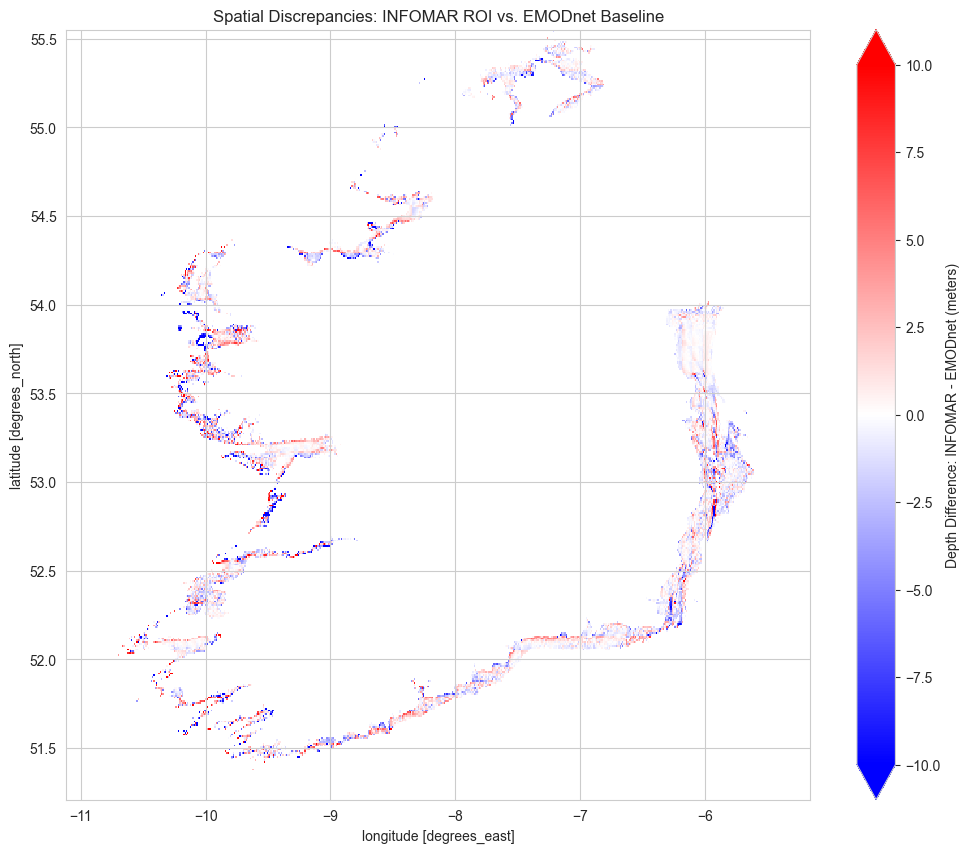

In [189]:
plt.figure(figsize=(12,10))
diff_grid.plot.imshow(
    cmap='bwr',
    vmin=-10,   # Red indicates EMODnet is deeper by 5m+
    vmax=10,    # Blue indicates INFOMAR is deeper by 5m+
    cbar_kwargs={'label': 'Depth Difference: INFOMAR - EMODnet (meters)'}
)

plt.title('Spatial Discrepancies: INFOMAR ROI vs. EMODnet Baseline')
plt.savefig('diff_grid.png', dpi=1200)
plt.show()

Here, this is showing that in the red areas, EMODnet depth is greater than INFOMAR depth, and in the blue areas, INFOMAR is deeper than EMODnet. Overall, it looks like EMODnet calculates the water deeper than it actually is. This means that EMODnet's coarser resolution was skipping over areas that might be relevant for mapping kelp, and EMODnet would have assumed that the water column is deeper than it actually is, meaning that I would have calculated that less light is reaching the seabed than actually is.

In [190]:
coast_bath.to_netcdf("coastal_bathymetry_ireland.nc")

In [191]:
coast_bath = xr.open_dataset("coastal_bathymetry_ireland.nc")
diff_grid = xr.open_dataset('bathymetry_diff_infomar_emodnet.nc')

# Integrated Surface PAR

**request form:** https://ads.atmosphere.copernicus.eu/datasets/cams-gridded-solar-radiation?tab=download

**doi and citation:** https://ads.atmosphere.copernicus.eu/datasets/cams-gridded-solar-radiation?tab=overview

1. Work with API to get data for one year randomly selected *(This looks really compilicated because it was a pain. There were ghost files and wrong files and all that so most of it is getting rid of the ghost folders, creating the new folder, api scrapping, then checking to make sure I am saving the right files where I want them).*


In [ ]:
import cdsapi
import xarray as xr
import zipfile
import os
import shutil
# 1. Setup brand new, untouched filenames and directories
zip_filename = "cams_fresh_data.zip"  # New name to avoid any broken files
extract_folder = "cams_extracted_fresh"

# Wipe old folders completely clean if they exist
if os.path.exists(extract_folder):
    shutil.rmtree(extract_folder, ignore_errors=True)
os.makedirs(extract_folder, exist_ok=True)

if os.path.exists(zip_filename):
    try:
        os.remove(zip_filename)
    except PermissionError:
        pass

# 2. Download a guaranteed fresh copy from CAMS
client = cdsapi.Client()
dataset = "cams-gridded-solar-radiation"
request = {
    "variable": ["global_horizontal_irradiation"],
    "sky_type": ["observed_cloud"],
    "version": ["4.6_rev2"],
    "year": ["2016"],
    "month": [
        "01", "02", "03", "04", "05", "06",
        "07", "08", "09", "10", "11", "12"
    ],
    "area": [55.5, -12, 51.21, -5.15],
    "format": "netcdf"
}

print("Downloading fresh CAMS data archive...")
client.retrieve(dataset, request).download(zip_filename)

# 3. Extract the healthy archive
print("\nExtracting files...")
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

# Let's get a list of all extracted files
extracted_files = [
    os.path.join(extract_folder, f)
    for f in os.listdir(extract_folder)
    if f.endswith('.nc')
]

# Quick print-out check to make sure sizes look normal (> 0 MB)
print(f"\nVerification: Found {len(extracted_files)} files.")
for f in extracted_files:
    size_mb = os.path.getsize(f) / 1024 / 1024
    print(f" -> {os.path.basename(f)} | Size: {size_mb:.2f} MB")

# 4. Open multi-file dataset seamlessly
print("\nLoading datasets together into Xarray...")

In [192]:
ds_cams = xr.open_mfdataset(extracted_files, combine="by_coords")

print("\n--- Dataset Successfully Loaded Together ---")
print(ds_cams)

NameError: name 'extracted_files' is not defined

### For when already have data downloaded:

In [193]:
import os
import zipfile
import xarray as xr

zip_path = "cams_fresh_data.zip"
extract_folder = "cams_extracted"

# 1. Check the zip file format
file_size = os.path.getsize(zip_path)
print(f"ZIP File size: {file_size / 1024 / 1024:.2f} MB")

with open(zip_path, "rb") as f:
    print(f"ZIP Beginning bytes: {f.read(100)}")

print("-" * 50)

# 2. Clean extraction into the folder
print("Extracting files...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print(f"Extracted files: {os.listdir(extract_folder)}")
print("-" * 50)

# 3. Open all files seamlessly using the original clean style
print("Loading dataset into Xarray...")
ds_cams = xr.open_mfdataset(f"{extract_folder}/*.nc", combine="by_coords")

print("\n--- Dataset Successfully Loaded Together ---")
print(ds_cams)

ZIP File size: 26.13 MB
ZIP Beginning bytes: b'PK\x03\x04\x14\x00\x00\x00\x08\x00\xbcc\xc9\\\t\x17\x87&\xc1\xeb\x16\x00\xdb\xea\x16\x00H\x00\x00\x00v4.6_rev2_GHI_observed_cloud_2016_01.area-subset.55.5.-5.15.51.21.-12.'
--------------------------------------------------
Extracting files...
Extracted files: ['v4.6_rev2_GHI_observed_cloud_2016_01.area-subset.55.5.-5.15.51.21.-12.nc', 'v4.6_rev2_GHI_observed_cloud_2016_02.area-subset.55.5.-5.15.51.21.-12.nc', 'v4.6_rev2_GHI_observed_cloud_2016_03.area-subset.55.5.-5.15.51.21.-12.nc', 'v4.6_rev2_GHI_observed_cloud_2016_04.area-subset.55.5.-5.15.51.21.-12.nc', 'v4.6_rev2_GHI_observed_cloud_2016_05.area-subset.55.5.-5.15.51.21.-12.nc', 'v4.6_rev2_GHI_observed_cloud_2016_06.area-subset.55.5.-5.15.51.21.-12.nc', 'v4.6_rev2_GHI_observed_cloud_2016_07.area-subset.55.5.-5.15.51.21.-12.nc', 'v4.6_rev2_GHI_observed_cloud_2016_08.area-subset.55.5.-5.15.51.21.-12.nc', 'v4.6_rev2_GHI_observed_cloud_2016_09.area-subset.55.5.-5.15.51.21.-12.nc', 'v4.6_r

2. Extract global horizontal irradiation (GHI) and get the mean value across time for the annual integrated value

In [194]:
annual_ghi = ds_cams['global_horizontal_irradiation'].mean(dim='time')

In [195]:
annual_ghi = annual_ghi.load()

In [278]:

#annual_ghi = annual_ghi.ffill(dim='longitude').bfill(dim='longitude').ffill(dim='latitude').bfill(dim='latitude')

In [196]:
from scipy.interpolate import griddata

In [197]:
lon_2d, lat_2d = np.meshgrid(annual_ghi.longitude.values, annual_ghi.latitude.values)

# Identify where valid, non-NaN atmospheric data actually exists
valid_mask = ~np.isnan(annual_ghi.values)

# Extract the coordinate pairs and their corresponding radiation values
points = np.stack([lon_2d[valid_mask], lat_2d[valid_mask]], axis=-1)
values = annual_ghi.values[valid_mask]

print("Extrapolating GHI seamlessly across the land-sea boundary...")
# Run a 2D nearest-neighbor interpolation to seamlessly fill the gaps
filled_values = griddata(
    points,
    values,
    (lon_2d, lat_2d),
    method='nearest'
)

# Reconstruct the filled numpy array back into your clean xarray DataArray
annual_ghi = xr.DataArray(
    filled_values,
    coords=annual_ghi.coords,
    dims=annual_ghi.dims,
    attrs=annual_ghi.attrs  # Preserves your original metadata attributes
)

print("Baseline GHI field successfully filled.")

Extrapolating GHI seamlessly across the land-sea boundary...
Baseline GHI field successfully filled.


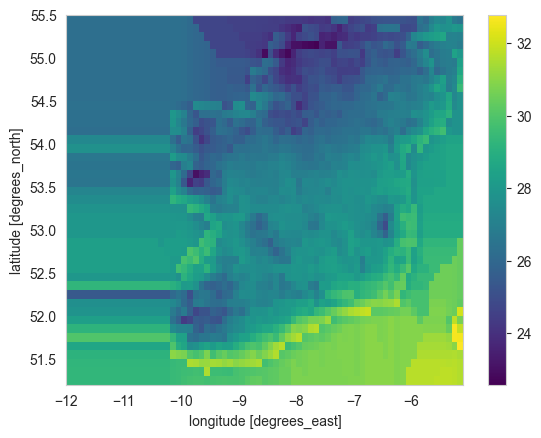

In [198]:
annual_ghi.plot()

**TRAP!:** This is not the annual ghi, but the ghi of a 15 minute window. Need to multiply by 4 to get per hour, then 24 to get per day, and then 365.25 to get per year.

In [199]:
annual_ghi = annual_ghi * 4 *24 * 365.25

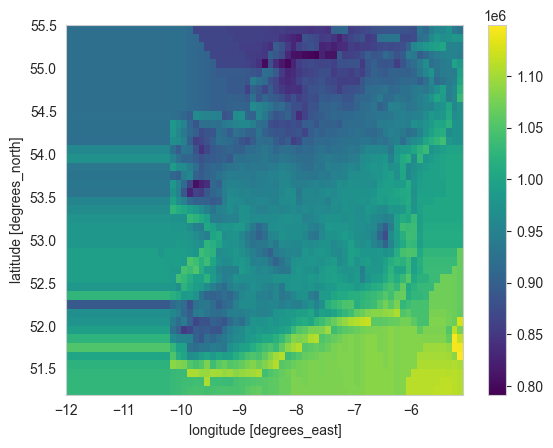

In [200]:
annual_ghi.plot()

3. Convert ghi to PAR using a value of 0.48 (see Moreno-Cuenca et al, Akitzu et al, and Proutsos et al in Anara for where that *estimated value comes from*)

In [201]:
annual_surfPAR = annual_ghi * 0.48

In [202]:
annual_surfPAR

<xarray.DataArray (latitude: 43, longitude: 69)> Size: 24kB
array([[441973.67252459, 441973.67252459, 441973.67252459, ...,
        465953.42478689, 450203.36577049, 446180.77770492],
       [441973.67252459, 441973.67252459, 441973.67252459, ...,
        467528.43068852, 471635.5172459 , 469535.12616393],
       [441973.67252459, 441973.67252459, 441973.67252459, ...,
        455732.55619672, 457022.45154098, 454548.42767213],
       ...,
       [492207.7384918 , 492207.7384918 , 492207.7384918 , ...,
        532717.58006557, 533020.51003279, 531694.40104918],
       [493141.24563934, 493141.24563934, 493141.24563934, ...,
        534493.77285246, 533871.24314754, 531844.42898361],
       [493141.24563934, 493141.24563934, 493141.24563934, ...,
        534493.77285246, 533871.24314754, 531844.42898361]],
      shape=(43, 69))
Coordinates:
  * latitude   (latitude) float32 172B 55.45 55.35 55.25 ... 51.45 51.35 51.25
  * longitude  (longitude) float32 276B -11.95 -11.85 -11.75 ... -5.25 -5.15

4. add attributes to match new values

In [203]:
annual_surfPAR.attrs['units'] = 'Wh m-2 y-1'
annual_surfPAR.attrs['long_name'] = 'Climatological Annual Surface PAR (Cloud Adjusted)'

5. use .rio.write_crs() to get it in the right grid format for the snap
6. use .rio.reproject_match() to snap it to the coast_bath pixels to get my area of interest

In [204]:
annual_surfPAR = annual_surfPAR.rio.write_crs('EPSG:4326')
surfPAR_1km = annual_surfPAR.rio.reproject_match(coast_bath, all_touched=True)

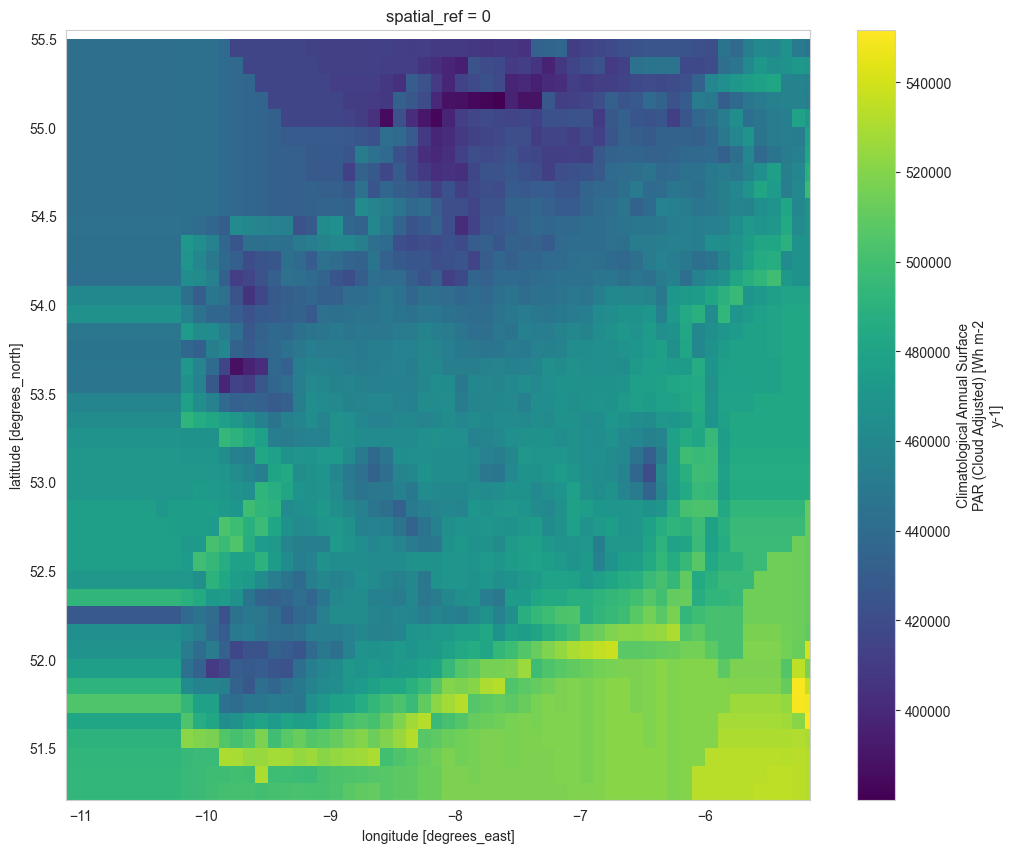

In [205]:
plt.figure(figsize=(12,10))
surfPAR_1km.plot()

7. Want to use coast_bath as a buffer to get rid of the island data and just have coast

In [206]:
coast_surfPAR = surfPAR_1km.where(coast_bath['elevation'].notnull())


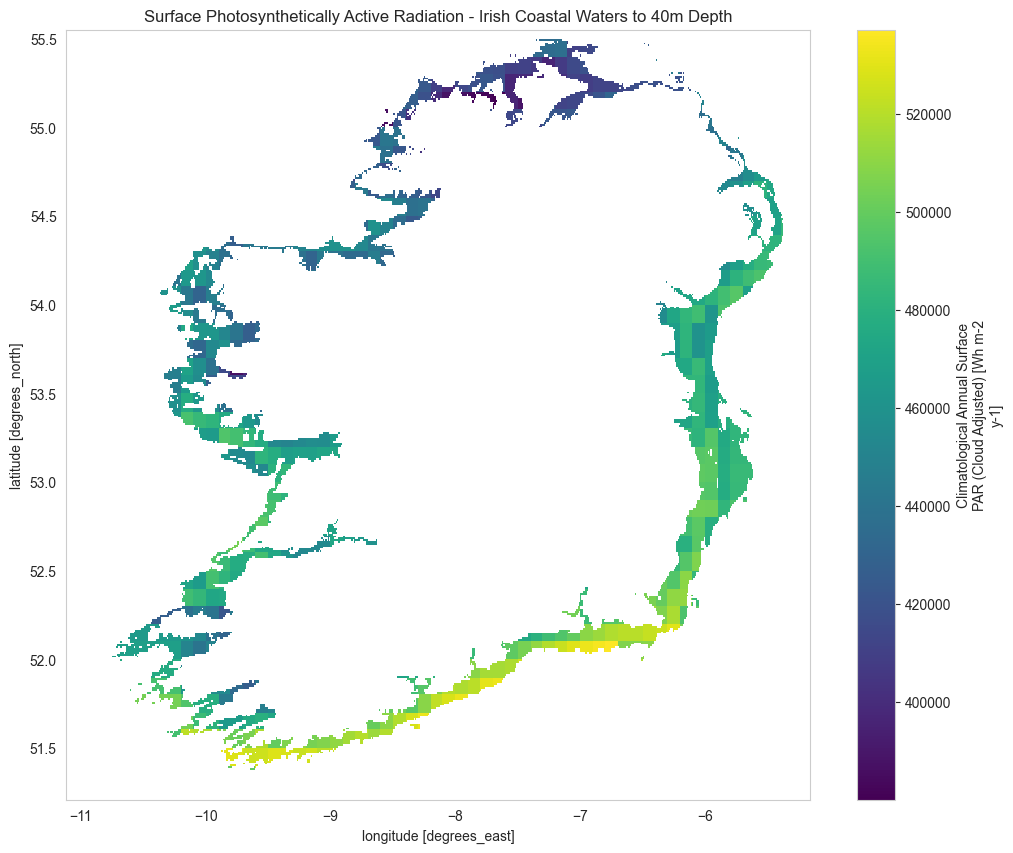

In [207]:
plt.figure(figsize=(12,10))
coast_surfPAR.plot()
plt.title("Surface Photosynthetically Active Radiation - Irish Coastal Waters to 40m Depth")


plt.savefig('surfacePAR_irishcoast.png', dpi=1200)
plt.show()

**FINALLY** got it to work, but I want to see how this compares to NASA PAR values, as the interpolation to get the area off of western Cork changed this up a bit. If I don't have to interpolate, I don't want to.

### NASA Data for Surface PAR

Source: https://power.larc.nasa.gov/data-access-viewer/
Temporal: Monthly&Annual
Parameter: All Sky Surface PAR

In [248]:
nasa_PAR = xr.open_dataset("C:/Users/25298423/OneDrive - National University of Ireland, Galway/Desktop/Data_Downloads/NASA_surfacePAR/POWER_Regional_Monthly_1997_2025.nc")

In [249]:
nasa_PAR

<xarray.Dataset> Size: 93kB
Dimensions:             (time: 375, lat: 5, lon: 6)
Coordinates:
  * time                (time) int64 3kB 199701 199702 199703 ... 202510 202511
  * lat                 (lat) float64 40B 51.5 52.5 53.5 54.5 55.5
  * lon                 (lon) float64 48B -10.5 -9.5 -8.5 -7.5 -6.5 -5.5
Data variables:
    ALLSKY_SFC_PAR_TOT  (time, lat, lon) float64 90kB ...
Attributes: (12/22)
    acknowledgement:           The Prediction Of Worldwide Energy Resources (...
    comment:                   POWER data version 10.0.0 uses the source data...
    conventions:               CF-1.8, ACDD-1.3
    creator_email:             bradley.macpherson@nasa.gov
    creator_name:              Bradley Macpherson
    derived_from:              The data products are derived from data partne...
    ...                        ...
    publisher_name:            Paul Stackhouse
    references:                https://power.larc.nasa.gov
    source:                    Prediction Of Worldwide Energy Resource (POWER)
    standard_name_vocabulary:  CF Standard Name Table v72
    summary:                   The POWER project provides solar and meteorolo...
    version:                   POWER Version 10.0.0

In [253]:
nasa_PAR_mean = nasa_PAR['ALLSKY_SFC_PAR_TOT'].mean(dim='time')

In [254]:
nasa_PAR_mean.attrs

{}

In [255]:


nasa_PAR_mean = nasa_PAR_mean.rio.write_crs('EPSG:4326')
nasa_PAR_1km = nasa_PAR_mean.rio.reproject_match(coast_bath, all_touched=True)

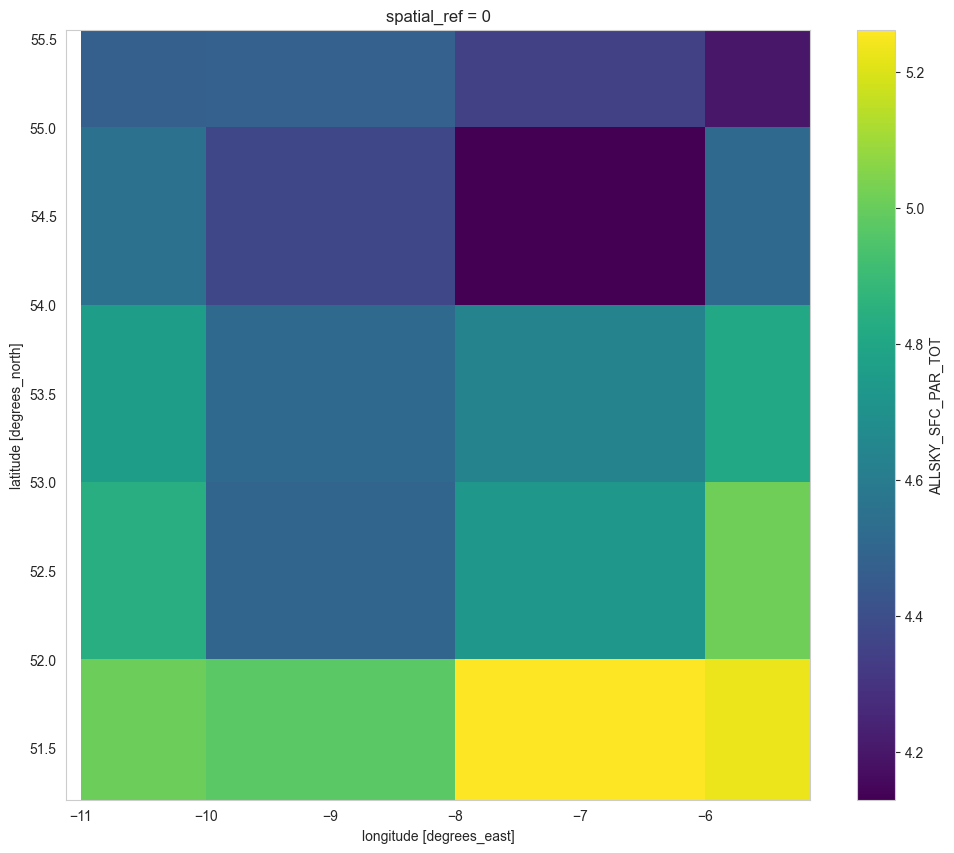

In [256]:
plt.figure(figsize=(12, 10))
nasa_PAR_1km.plot()

### NASA is boofy, try to use Copernicus
shocker...couldn't find PAR anyfuckingwhere

So NASA had very low spatial resolution, and copernicus straight up did not have it (that I could tell). Uses a different kind of interpolation from scipy to make it a bit better. Tomorrow, need to start pulling in Kd490 data to start doing some mathhhhh

**NOW: Convert Wh to mol photons**

In [208]:
coast_surfPAR_mol = coast_surfPAR * 3600 * (4.57 * 10**-6)

In [209]:
coast_surfPAR_mol.attrs['units'] = 'mol photons m-2 y-1'
annual_surfPAR.attrs['long_name'] = 'Climatological Annual Surface PAR (Cloud Adjusted)'

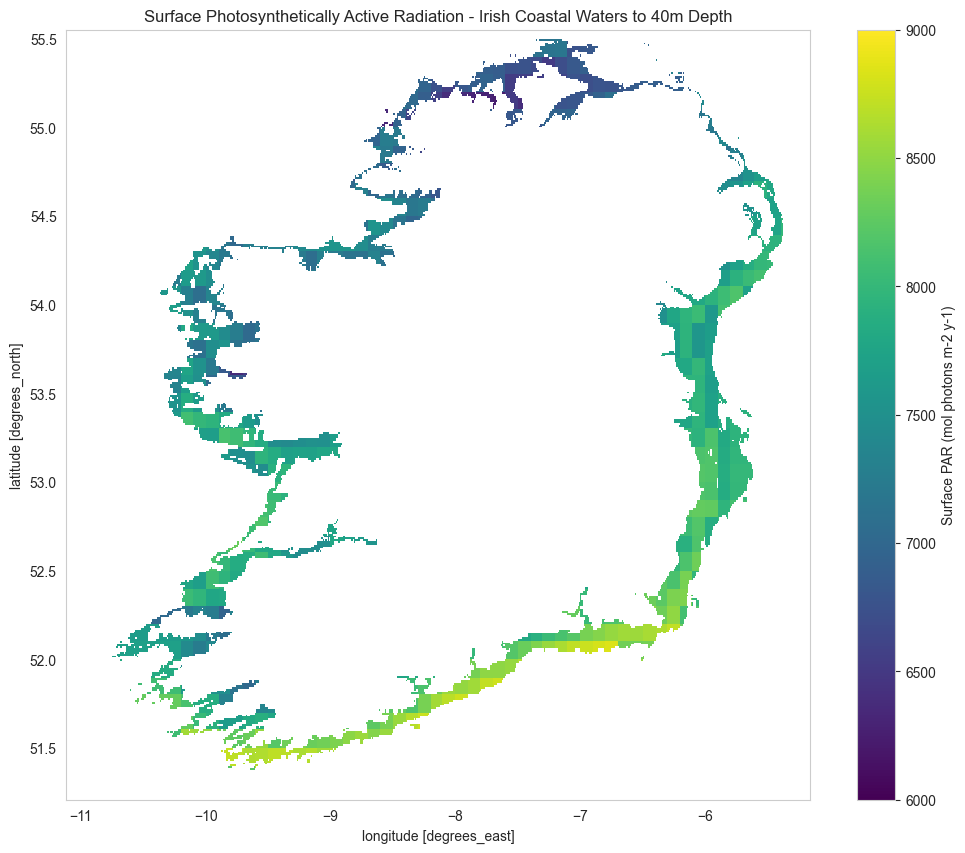

In [210]:
plt.figure(figsize=(12,10))
coast_surfPAR_mol.plot(
    vmax=9000,
    vmin=6000,
    cbar_kwargs={'label': 'Surface PAR (mol photons m-2 y-1)'},
)
plt.title("Surface Photosynthetically Active Radiation - Irish Coastal Waters to 40m Depth")


plt.savefig('surfacePAR_mol_irishcoast.png', dpi=1200)
plt.show()

In [211]:
coast_surfPAR_mol.to_netcdf("coastal_surface_PAR_photonmol.nc")

# Kd490 Data

In [248]:
file_list = sorted(glob.glob('/home/jovyan/notmessedup_directory/*.nc'))
kd490_ds = xr.open_mfdataset(file_list, concat_dim='time', combine='nested')
## combine all the files into one, massive DataSet so that we can do comparisons over years
kd490_ds

<xarray.Dataset> Size: 54GB
Dimensions:    (time: 10228, latitude: 1056, longitude: 1248)
Coordinates:
  * time       (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude   (latitude) float32 4kB 48.01 48.02 48.03 ... 58.97 58.98 58.99
  * longitude  (longitude) float32 5kB -14.99 -14.98 -14.97 ... -2.016 -2.005
Data variables:
    KD490      (time, latitude, longitude) float32 54GB dask.array<chunksize=(119, 1056, 1248), meta=np.ndarray>
Attributes:
    references:                http://www.globcolour.info GlobColour has been...
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    copernicusmarine_version:  2.2.2

In [249]:
coast_bath

<xarray.Dataset> Size: 13MB
Dimensions:             (band: 1, y: 417, x: 572)
Coordinates:
  * band                (band) int64 8B 1
  * y                   (y) float32 2kB 51.21 51.22 51.23 ... 55.53 55.54 55.55
  * x                   (x) float32 2kB -11.11 -11.1 -11.09 ... -5.172 -5.161
    spatial_ref         int64 8B ...
Data variables:
    elevation           (band, y, x) float64 2MB nan nan nan nan ... nan nan nan
    value_count         (band, y, x) float64 2MB ...
    cdi_index           (band, y, x) float64 2MB ...
    interpolation_flag  (band, y, x) float64 2MB ...
    elevation_max       (band, y, x) float64 2MB ...
    elevation_min       (band, y, x) float64 2MB ...
    stdev               (band, y, x) float64 2MB ...
Attributes: (12/36)
    cdm_data_type:                    Grid
    comment:                          The data in the EMODnet Grid should not...
    Conventions:                      SeaDataNet_1.0 CF1.6, COARDS, ACDD-1.3
    creator_name:                     SeaDataNet
    creator_url:                      https://www.seadatanet.org/
    dtm_convention_version:           1.0
    ...                               ...
    sourceUrl:                        (local files)
    Southernmost_Northing:            51.20468749996878
    standard_name_vocabulary:         CF Standard Name Table v70
    summary:                          The data in the EMODnet Grid should not...
    title:                            The EMODnet Grid
    Westernmost_Easting:              -11.1171875000143

In [250]:
coast_mask_dataset = coast_bath.rename({'y': 'latitude','x':'longitude'})

In [251]:
kd490_ds = kd490_ds.where(coast_mask_dataset['elevation'].notnull())

In [252]:
kd490_ds

<xarray.Dataset> Size: 10GB
Dimensions:      (time: 10228, latitude: 417, longitude: 572, band: 1)
Coordinates:
  * time         (time) datetime64[ns] 82kB 1997-09-04 1997-09-05 ... 2025-09-04
  * latitude     (latitude) float32 2kB 51.21 51.22 51.23 ... 55.53 55.54 55.55
  * longitude    (longitude) float32 2kB -11.11 -11.1 -11.09 ... -5.172 -5.161
  * band         (band) int64 8B 1
    spatial_ref  int64 8B ...
Data variables:
    KD490        (time, latitude, longitude, band) float32 10GB dask.array<chunksize=(119, 417, 572, 1), meta=np.ndarray>
Attributes:
    references:                http://www.globcolour.info GlobColour has been...
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    copernicusmarine_version:  2.2.2

1. First problem is that my years are not perfect years, they run from September 4ths yearly. Need to shift the timeline back to make it easier, but still keep in mind that "1997" is "Sept 1997 to Sept 1998"

In [253]:
kd490_ds = kd490_ds.chunk({"time": -1, "latitude": 250, "longitude": 250})
shift = kd490_ds.time - np.timedelta64(246, 'D')
kd490_shifted = kd490_ds.assign_coords(shifted_year = shift.dt.year)

2. Calc yearly medians

In [254]:
kd490_yr_median = kd490_shifted.groupby('shifted_year').median('time')

3. Drop the last year as it doesn't really exist anymore

In [255]:
kd490_yr_median = kd490_yr_median.sel(shifted_year=slice(None, 2024))

4. Define the x array (years)

In [256]:
baseline_year = 1997
x_values = kd490_yr_median.shifted_year.values - baseline_year

5. Use the fit_with_uncertainty() and xr.apply_ufunc() to compute the **linear regression**

In [257]:
def fit_with_uncertainty(y, x, min_points=20):
    mask = np.isfinite(y)
    if mask.sum() < min_points:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    res = stats.linregress(x[mask], y[mask])
    return (
        res.slope,
        res.intercept,
        res.rvalue,
        res.pvalue,
        res.stderr,
        getattr(res, "intercept_stderr", np.nan)
    )



slope, intercept, rvalue, pvalue, slope_stderr, intercept_stderr = xr.apply_ufunc(
    fit_with_uncertainty,
    kd490_yr_median,
    input_core_dims=[['shifted_year']],
    output_core_dims=[[], [], [], [], [], []],
    vectorize=True,
    dask='parallelized',
    dask_gufunc_kwargs={'allow_rechunk': True},
    output_dtypes=[float, float, float, float, float, float],
    kwargs={'x': x_values, 'min_points': 20}
)

6. Save the intercept for the calculations later (1997 modelled baseline)

In [258]:
kd490_1997_modeled = intercept

7. Calculate the 2025 model

In [259]:
kd490_2025_modeled = intercept + (slope * 28.0)

Great! those are made for the comparison.

**NOW:** Need to calculate the overall yearly median value for the whole time series, and make a case1 and case2 mask

In [34]:
#kd490_total_median = kd490_yr_median.median(dim='shifted_year')

In [260]:
kd490_shifted

<xarray.Dataset> Size: 10GB
Dimensions:       (time: 10228, latitude: 417, longitude: 572, band: 1)
Coordinates:
  * time          (time) datetime64[ns] 82kB 1997-09-04 ... 2025-09-04
  * latitude      (latitude) float32 2kB 51.21 51.22 51.23 ... 55.53 55.54 55.55
  * longitude     (longitude) float32 2kB -11.11 -11.1 -11.09 ... -5.172 -5.161
  * band          (band) int64 8B 1
    spatial_ref   int64 8B ...
    shifted_year  (time) int64 82kB 1997 1997 1997 1997 ... 2024 2024 2024 2025
Data variables:
    KD490         (time, latitude, longitude, band) float32 10GB dask.array<chunksize=(10228, 250, 250, 1), meta=np.ndarray>
Attributes:
    references:                http://www.globcolour.info GlobColour has been...
    contact:                   servicedesk.cmems@acri-st.fr
    Conventions:               CF-1.8, ACDD-1.3
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    institution:               ACRI
    title:                     cmems_obs-oc_atl_bgc-transp_my_l3-multi-1km_P1D
    copernicusmarine_version:  2.2.2

In [261]:
kd490_total_median = kd490_shifted.median(dim='time')
kd490_total_median

<xarray.Dataset> Size: 958kB
Dimensions:      (latitude: 417, longitude: 572, band: 1)
Coordinates:
  * latitude     (latitude) float32 2kB 51.21 51.22 51.23 ... 55.53 55.54 55.55
  * longitude    (longitude) float32 2kB -11.11 -11.1 -11.09 ... -5.172 -5.161
  * band         (band) int64 8B 1
    spatial_ref  int64 8B ...
Data variables:
    KD490        (latitude, longitude, band) float32 954kB dask.array<chunksize=(250, 250, 1), meta=np.ndarray>

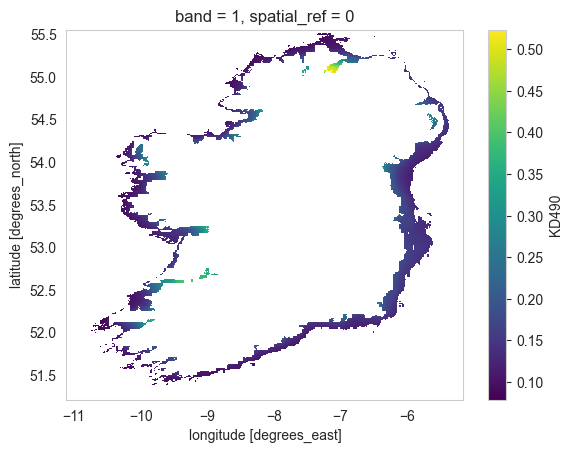

In [263]:
kd490_total_median['KD490'].plot()

In [271]:
case1_mask = kd490_total_median <= 0.115
case2_mask = kd490_total_median > 0.115

Want to check it out, so combine masks into one water classification and plot

In [272]:
import numpy as np
import xarray as xr

# 1. Pull the actual boolean array variable OUT of the dataset container
conditions = [
    case1_mask['KD490'].values,  # Accessing the variable grid directly
    case2_mask['KD490'].values
]
choices = [1, 2]

# 2. Run the fast NumPy selection (defaulting to NaN for everything else)
fast_classified_matrix = np.select(conditions, choices, default=np.nan)

# 3. Put it right back into an Xarray DataArray using your existing structure
water_class = xr.DataArray(
    data=fast_classified_matrix,
    coords=kd490_total_median.coords,
    dims=kd490_total_median.dims
)

print("Classification complete!")
print(water_class)

Classification complete!
<xarray.DataArray (latitude: 417, longitude: 572, band: 1)> Size: 2MB
array([[[nan],
        [nan],
        [nan],
        ...,
        [nan],
        [nan],
        [nan]],

       [[nan],
        [nan],
        [nan],
        ...,
        [nan],
        [nan],
        [nan]],

       [[nan],
        [nan],
        [nan],
        ...,
...
        ...,
        [nan],
        [nan],
        [nan]],

       [[nan],
        [nan],
        [nan],
        ...,
        [nan],
        [nan],
        [nan]],

       [[nan],
        [nan],
        [nan],
        ...,
        [nan],
        [nan],
        [nan]]], shape=(417, 572, 1))
Coordinates:
  * latitude     (latitude) float32 2kB 51.21 51.22 51.23 ... 55.53 55.54 55.55
  * longitude    (longitude) float32 2kB -11.11 -11.1 -11.09 ... -5.172 -5.161
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0


In [36]:
#water_class = xr.where(case1_mask, 1, xr.where(case2_mask, 2, np.nan))

C:\Users\25298423\PycharmProjects\JupyterProject1\.venv\Lib\site-packages\dask\array\core.py:4997: PerformanceWarning: Increasing number of chunks by factor of 32
  result = blockwise(


In [ ]:
#water_class = water_class.compute()

In [ ]:
##water_class.p lot()

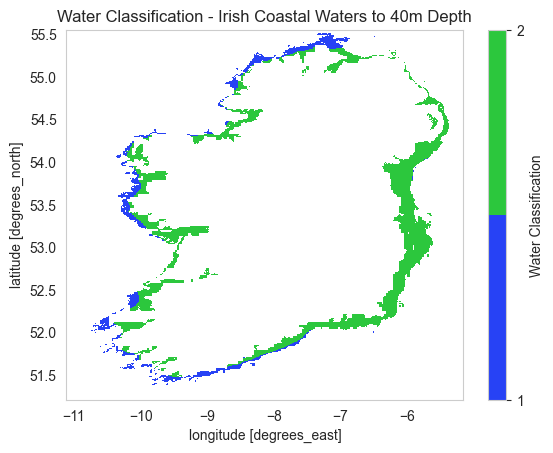

In [279]:
from matplotlib.colors import ListedColormap
water_class.plot(
    cmap = ListedColormap(['#2742F5','#2CC73D']),
    vmin=1,
    vmax=2,
    cbar_kwargs={
        'ticks': [1,2],
        'label': 'Water Classification'
    }
)
plt.title("Water Classification - Irish Coastal Waters to 40m Depth")
plt.show()

Now! Need to use this dataset to perform equations on KD490 to get kdPAR

## Convert to KdPAR

In [280]:
kd490 = kd490_shifted['KD490']

In [281]:
case1_equation = (4.6051 * kd490)/(6.0700* kd490 + 3.200)
case2_equation = 0.81008 * (kd490 ** 0.8256)

In [282]:
kdpar = xr.where(water_class == 1, case1_equation, case2_equation)

In [283]:
kdpar_shifted_ds = kdpar.to_dataset(name='KDPAR')

In [284]:
kdpar_shifted_ds

<xarray.Dataset> Size: 10GB
Dimensions:       (latitude: 417, longitude: 572, band: 1, time: 10228)
Coordinates:
  * latitude      (latitude) float32 2kB 51.21 51.22 51.23 ... 55.53 55.54 55.55
  * longitude     (longitude) float32 2kB -11.11 -11.1 -11.09 ... -5.172 -5.161
  * band          (band) int64 8B 1
  * time          (time) datetime64[ns] 82kB 1997-09-04 ... 2025-09-04
    spatial_ref   int64 8B 0
    shifted_year  (time) int64 82kB 1997 1997 1997 1997 ... 2024 2024 2024 2025
Data variables:
    KDPAR         (latitude, longitude, band, time) float32 10GB dask.array<chunksize=(250, 250, 1, 10228), meta=np.ndarray>

2. Compute median for every shifted year

In [285]:
kdpar_yr_median = kdpar_shifted_ds.groupby('shifted_year').median('time')

3. Drop the last year as it doesn't really exist anymore

In [286]:
kdpar_yr_median = kdpar_yr_median.sel(shifted_year=slice(None, 2024))

3.5 Compute overall median

In [288]:
kdpar_total_median = kdpar_shifted_ds.median(dim='time')

4. Define
the
x
array(years)

In [289]:
baseline_year = 1997
x_values = kdpar_yr_median.shifted_year.values - baseline_year

5. Use
the
fit_with_uncertainty() and xr.apply_ufunc()
to
compute
the ** linear
regression **


In [290]:

def fit_with_uncertainty(y, x, min_points=20):
    mask = np.isfinite(y)
    if mask.sum() < min_points:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    res = stats.linregress(x[mask], y[mask])
    return (
        res.slope,
        res.intercept,
        res.rvalue,
        res.pvalue,
        res.stderr,
        getattr(res, "intercept_stderr", np.nan)
    )


slope, intercept, rvalue, pvalue, slope_stderr, intercept_stderr = xr.apply_ufunc(
    fit_with_uncertainty,
    kdpar_yr_median,
    input_core_dims=[['shifted_year']],
    output_core_dims=[[], [], [], [], [], []],
    vectorize=True,
    dask='parallelized',
    dask_gufunc_kwargs={'allow_rechunk': True},
    output_dtypes=[float, float, float, float, float, float],
    kwargs={'x': x_values, 'min_points': 20}
)

In [298]:
import xarray as xr

# 1. Safely rename the internal variable of each dataset before merging
# (Assuming 'KDPAR' is the exact name throwing the error)
slope_renamed = slope.rename({'KDPAR': 'slope'})
intercept_renamed = intercept.rename({'KDPAR': 'intercept'})
rvalue_renamed = rvalue.rename({'KDPAR': 'rvalue'})
pvalue_renamed = pvalue.rename({'KDPAR': 'pvalue'})
slope_stderr_renamed = slope_stderr.rename({'KDPAR': 'slope_stderr'})
intercept_stderr_renamed = intercept_stderr.rename({'KDPAR': 'intercept_stderr'})

# 2. Merge the uniquely named datasets cleanly
regression_ds = xr.merge([
    slope_renamed,
    intercept_renamed,
    rvalue_renamed,
    pvalue_renamed,
    slope_stderr_renamed,
    intercept_stderr_renamed
])

# 3. Compute and save to your local NetCDF file
print("Computing and saving regression results to file... (this may take a few minutes)")
regression_ds.to_netcdf('kdpar_linear_regression_results.nc')
print("Successfully saved to 'kdpar_linear_regression_results.nc'!")

Computing and saving regression results to file... (this may take a few minutes)
Successfully saved to 'kdpar_linear_regression_results.nc'!


In [299]:
reg_data = xr.open_dataset('kdpar_linear_regression_results.nc')

6. Save
the
intercept|
for the calculations later (1997 modelled baseline)

In [300]:
intercept = reg_data['intercept']
slope = reg_data['slope']

In [301]:
kdpar_1997_modeled = intercept

7. Calculate
the
2025
model

In [302]:
kdpar_2025_modeled = intercept + (slope * 28.0)

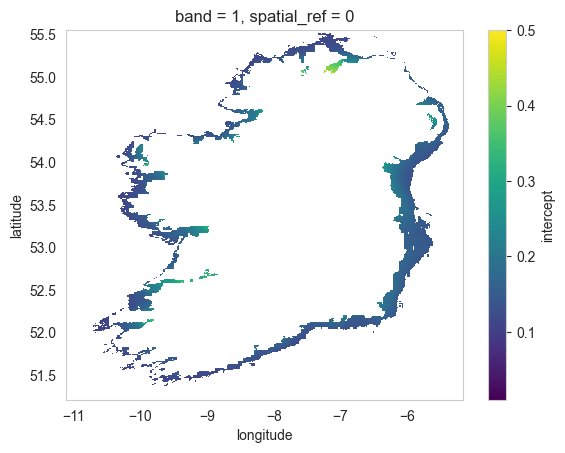

In [307]:
kdpar_1997_modeled.plot(
    vmin= 0.01,
    vmax = 0.50
)

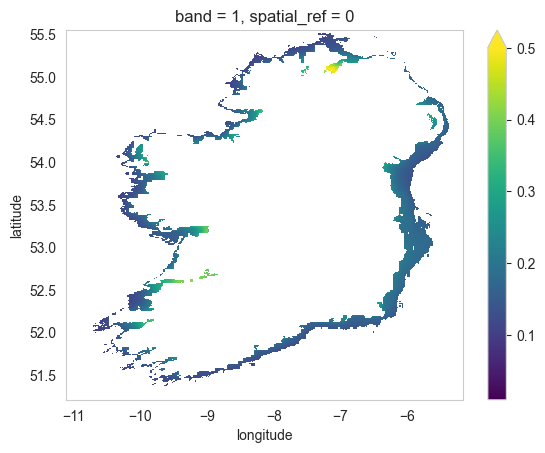

In [306]:
kdpar_2025_modeled.plot(
    vmin= 0.01,
    vmax = 0.50
)

Now, use the Beer-Lambert equation to get the light profiles

In [313]:
coast_surfPAR_mol = xr.open_dataset('C:/Users/25298423/PycharmProjects/JupyterProject1/coastal_surface_PAR_photonmol.nc')

In [316]:
coast_surfPAR_mol = coast_surfPAR_mol.rename({'__xarray_dataarray_variable__': 'surface_PAR'})

In [317]:
coast_surfPAR_mol

<xarray.Dataset> Size: 2MB
Dimensions:      (y: 417, x: 572, band: 1)
Coordinates:
  * y            (y) float32 2kB 51.21 51.22 51.23 51.24 ... 55.53 55.54 55.55
  * x            (x) float32 2kB -11.11 -11.1 -11.09 ... -5.182 -5.172 -5.161
  * band         (band) int64 8B 1
    spatial_ref  int64 8B ...
Data variables:
    surface_PAR  (y, x, band) float64 2MB ...

In [314]:
depth_array = np.arange(0,41,1)
z = xr.DataArray(depth_array, dims=['depth'], coords={'depth': depth_array})
z

<xarray.DataArray (depth: 41)> Size: 328B
array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40])
Coordinates:
  * depth    (depth) int64 328B 0 1 2 3 4 5 6 7 8 ... 32 33 34 35 36 37 38 39 40

In [320]:
kdpar_1997_modeled = kdpar_1997_modeled.rename({'latitude':'y','longitude':'x'})
kdpar_2025_modeled = kdpar_2025_modeled.rename({'latitude':'y','longitude':'x'})

In [321]:
# Calc the Beer-Lambert light attenuation profiles
iz_1997 = coast_surfPAR_mol['surface_PAR'] * np.exp(-kdpar_1997_modeled * z)
iz_2025 = coast_surfPAR_mol['surface_PAR'] * np.exp(-kdpar_2025_modeled * z)

In [323]:
lightscape_profiles = xr.Dataset(
    data_vars={
        'I_1997': iz_1997,
        'I_2025': iz_2025
    }
)

In [325]:
lightscape_profiles['depth'].attrs = {'units': 'm', 'long_name': 'Water Depth'}
lightscape_profiles['I_1997'].attrs = {'units': 'mol photon m-2 y-1', 'description': 'Available PAR down profile in 1997'}
lightscape_profiles['I_2025'].attrs = {'units': 'mol photon m-2 y-1', 'description': 'Available PAR down profile in 2025'}

In [326]:
lightscape_profiles.to_netcdf("lightscape_profiles.nc")

In [327]:
# 1. Get the spatial averages for the two different years
avg_I_1997 = lightscape_profiles['I_1997'].mean(dim=['y','x'])
avg_I_2025 = lightscape_profiles['I_2025'].mean(dim=['y','x'])

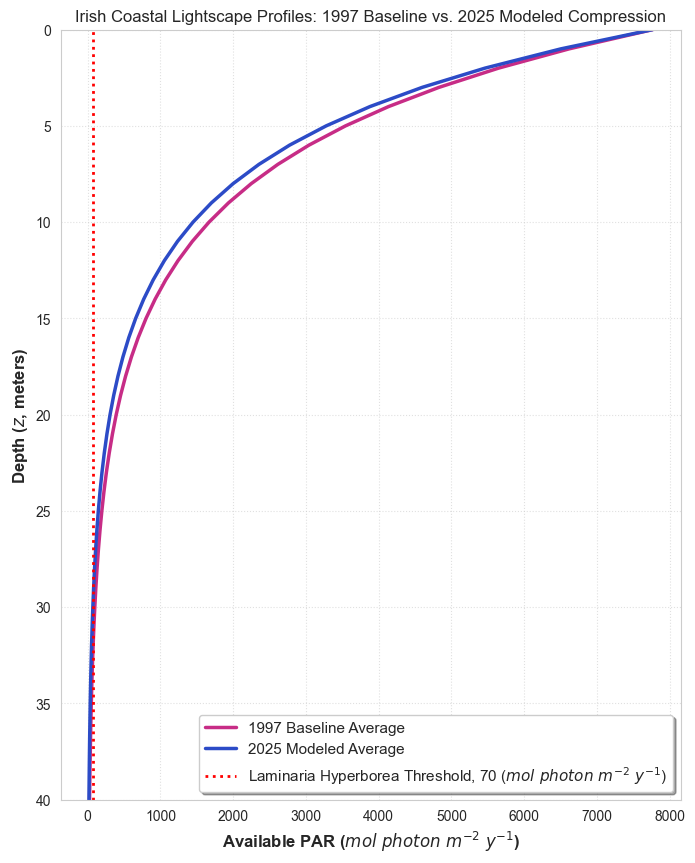

In [337]:
fig, ax = plt.subplots(figsize=(8,10))

x_1997 = avg_I_1997.squeeze()
x_2025 = avg_I_2025.squeeze()

ax.plot(x_1997, x_1997.coords['depth'], label='1997 Baseline Average', color = '#C72C86', linewidth = 2.5)
ax.plot(x_2025, x_2025.coords['depth'], label='2025 Modeled Average', color = '#2C4BC7', linewidth = 2.5)

laminaria_hyperborea_thresh = 70
ax.axvline(x=laminaria_hyperborea_thresh, color='red',linestyle =':', linewidth =2, label = r'Laminaria Hyperborea Threshold, 70 ($mol\ photon\ m^{-2}\ y^{-1}$)')

ax.invert_yaxis()
ax.set_ylim(40,0)

ax.set_xlabel(r'Available PAR ($mol\ photon\ m^{-2}\ y^{-1}$)', fontsize=12, fontweight='bold')
ax.set_ylabel(r'Depth ($z$, meters)', fontsize=12, fontweight='bold')
ax.set_title("Irish Coastal Lightscape Profiles: 1997 Baseline vs. 2025 Modeled Compression")

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)

plt.savefig('L_Hyperborea_lightscape_profiles.png', dpi=1200)
plt.show()

### Regional Analysis

In [345]:
regions = {
    'SW and Shannon Estuary': {'lat_slice': slice(51.42277, 52.75723), 'lon_slice': slice(-10.73634, -8.71712)},
    'Galway Bay': {'lat_slice': slice(53.08172, 53.27876), 'lon_slice': slice(-9.53443, -8.86586)},
    'Donegal': {'lat_slice': slice(54.62140, 55.247359), 'lon_slice': slice(-9.19486, -7.95719)},
    'NI and Louth': {'lat_slice': slice(53.58015, 54.25658), 'lon_slice': slice(-6.53082, -5.17)}
}

In [346]:
# 1. Galway
selected_region = 'Galway Bay'
box = regions[selected_region]

galway_profiles = lightscape_profiles.sel(
    x = box['lat_slice'],
    y = box['lon_slice'])

galway_avg_1997 = galway_profiles['I_1997'].mean(dim=['y','x'])
galway_avg_2025 = galway_profiles['I_2025'].mean(dim=['y','x'])


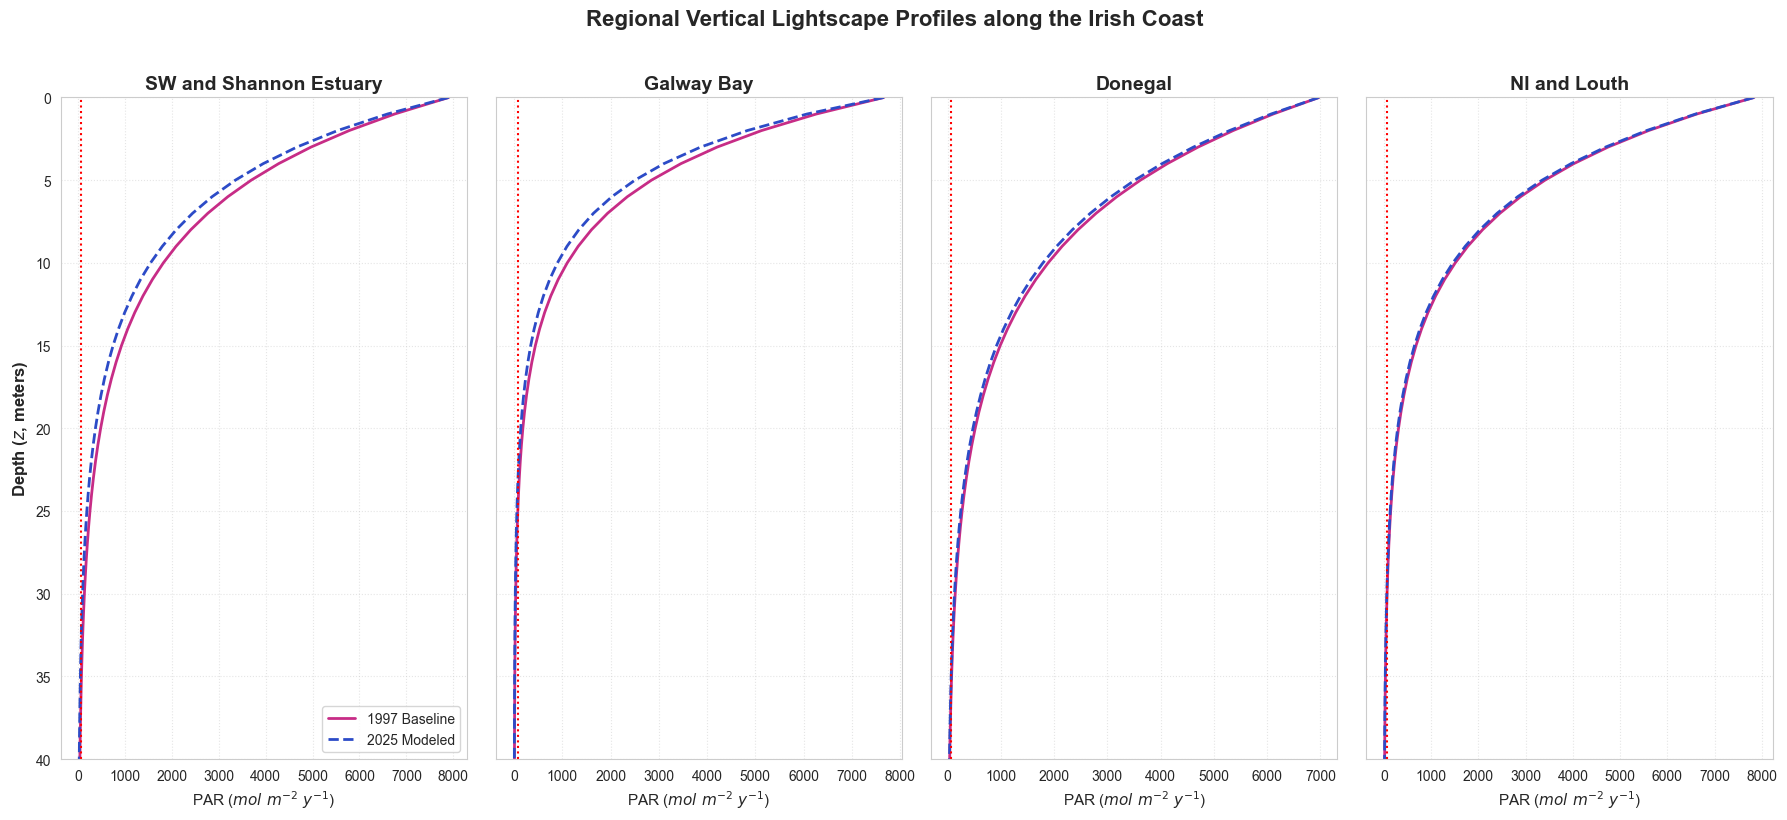

In [353]:
import matplotlib.pyplot as plt

# Set up a multi-panel figure side-by-side
fig, axes = plt.subplots(1, 4, figsize=(18, 8), sharey=True)
axes = axes.flatten()

laminaria_hyperborea_thresh = 70

for i, (region_name, box) in enumerate(regions.items()):
    ax = axes[i]

    # Slice and average the data for this specific region
    reg_data = lightscape_profiles.sel(y=box['lat_slice'], x=box['lon_slice'])
    y_depth = reg_data.coords['depth']

    x_1997 = reg_data['I_1997'].mean(dim=['x', 'y'], skipna=True).squeeze()
    x_2025 = reg_data['I_2025'].mean(dim=['x', 'y'], skipna=True).squeeze()

    # Plot the lines
    ax.plot(x_1997, y_depth, label='1997 Baseline', color='#C72C86', linewidth=2)
    ax.plot(x_2025, y_depth, label='2025 Modeled', color='#2C4BC7', linewidth=2, linestyle='--')

    # Threshold line
    ax.axvline(x=laminaria_hyperborea_thresh, color='red', linestyle=':', linewidth=1.5)

    # Force strict depth boundaries
    ax.set_ylim(40, 0)

    # Aesthetics
    ax.set_title(region_name, fontsize=14, fontweight='bold')
    ax.set_xlabel(r'PAR ($mol\ m^{-2}\ y^{-1}$)', fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.5)

    if i == 0:
        ax.set_ylabel('Depth ($z$, meters)', fontsize=12, fontweight='bold')
        ax.legend(loc='lower right', frameon=True)

plt.suptitle("Regional Vertical Lightscape Profiles along the Irish Coast", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('L_hyper_regional_lightscape_profiles.png', dpi=1200)
plt.show()

### Modeling Depth Distribution Changes

In [354]:
lightscape_profiles = xr.open_dataset('C:/Users/25298423/PycharmProjects/JupyterProject1/lightscape_profiles.nc')
laminaria_hyperborea_thresh = 70

In [ ]:
# 1. Find where light satisfies the threshold